# **TP Spotify — Modélisation de la popularité musicale**

<br>

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/8/84/Spotify_icon.svg" width="120">
</p>

<br>

## Contexte

Ce projet s’inscrit dans le cadre du module de **Machine Learning supervisé avec Python**.  
Il a pour objectif d’analyser des données issues de Spotify afin de comprendre les facteurs influençant la popularité des morceaux et de construire un modèle de classification prédictif.

<br>

## Objectifs

- Explorer et comprendre les caractéristiques audio des morceaux  
- Transformer la variable de popularité en classes exploitables  
- Nettoyer et préparer les données (valeurs manquantes, doublons, cohérence)  
- Identifier les relations entre variables  
- Construire et optimiser un modèle de classification  
- Évaluer la capacité du modèle à généraliser  

<br>

## Cadre académique

- **Module** : Machine Learning supervisé avec Python  
- **Programme** : NEXA School IA — Master 1  

<br>

## Équipe projet

- CASTERAS Maxime  
- DELGADO David  
- HIM Philippe  

<br>
<br>
<br>



<br>
<br>
<br>

## **1. Introduction du projet**

Ce projet vise à construire un modèle de classification permettant de prédire la popularité d’un morceau Spotify à partir de ses caractéristiques audio.

L’objectif est de comprendre quels facteurs musicaux influencent la popularité et de développer un modèle capable de prédire correctement ces classes.

<br>
<br>

In [51]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
import seaborn as sns

df_high_popularity = pd.read_csv('high_popularity_spotify_data (1).csv')
df_low_popularity = pd.read_csv('low_popularity_spotify_data (1).csv')

df_high_popularity["fichier_origine"] = "high"
df_low_popularity["fichier_origine"] = "low"


df_origin = pd.concat([df_high_popularity, df_low_popularity], ignore_index=True)

print(df_origin.shape)




(4831, 30)


In [52]:
df_origin.head(5)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,fichier_origine
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high



<br>
<br>
<br>

In [53]:
df_origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    4830 non-null   float64
 1   tempo                     4830 non-null   float64
 2   danceability              4830 non-null   float64
 3   playlist_genre            4831 non-null   object 
 4   loudness                  4830 non-null   float64
 5   liveness                  4830 non-null   float64
 6   valence                   4830 non-null   float64
 7   track_artist              4831 non-null   object 
 8   time_signature            4830 non-null   float64
 9   speechiness               4830 non-null   float64
 10  track_popularity          4831 non-null   int64  
 11  track_href                4830 non-null   object 
 12  uri                       4830 non-null   object 
 13  track_album_name          4830 non-null   object 
 14  playlist

<br>
<br><br>
<br>

## **2. Description des colonnes – Dataset Spotify**
<br>
<br>

| Colonne | Type | Description détaillée |
|--------|------|----------------------|
| energy | Numérique (0–1) | Mesure l’intensité globale du morceau en combinant plusieurs facteurs (volume perçu, activité sonore, densité). Une valeur élevée correspond à une musique rapide, forte et dynamique. |
| tempo | Numérique (BPM) | Vitesse du morceau exprimée en battements par minute. Influence directement le rythme perçu et l’énergie musicale. |
| danceability | Numérique (0–1) | Mesure la facilité à danser sur le morceau selon des critères comme la stabilité du rythme, la régularité et la présence d’un beat clair. |
| playlist_genre | Catégorielle | Genre principal de la playlist (ex : EDM, pop, rap, rock, jazz). Fournit un contexte global du style musical. |
| loudness | Numérique (dB) | Volume moyen du morceau en décibels. Généralement négatif. Plus la valeur est proche de 0, plus le morceau est perçu comme fort. |
| liveness | Numérique (0–1) | Probabilité que le morceau soit enregistré en live. Une valeur élevée indique la présence probable d’un public (concert, performance live). |
| valence | Numérique (0–1) | Mesure l’émotion musicale véhiculée : faible = triste/mélancolique, élevé = joyeux/positif. |
| track_artist | Texte | Nom de l’artiste du morceau. Peut contenir plusieurs artistes (collaborations) séparés par des virgules ou autres séparateurs (feat, &, etc.). |
| time_signature | Numérique | Signature rythmique du morceau (ex : 3 = 3/4, 4 = 4/4). Indique la structure des temps musicaux. |
| speechiness | Numérique (0–1) | Indique la présence de contenu parlé. Valeur élevée = forte présence de parole (rap, discours, podcast). |
| track_popularity | Numérique (0–100) | Score de popularité Spotify basé sur les écoutes, la récence et l’engagement. Variable cible principale en régression. |
| track_href | URL | Lien API Spotify du morceau. Donnée technique sans valeur analytique directe pour le Machine Learning. |
| uri | Texte | Identifiant unique Spotify au format URI (spotify:track:...). Utilisé pour accès API, non pertinent pour le ML. |
| track_album_name | Texte | Nom de l’album ou du single du morceau. Texte non structuré nécessitant du NLP pour exploitation. |
| playlist_name | Texte | Nom de la playlist contenant le morceau. Non exploitable directement sans traitement textuel. |
| analysis_url | URL | Lien vers l’analyse audio détaillée Spotify. Non exploitable directement sans appel API. |
| track_id | Texte | Identifiant unique du morceau. Sert de clé technique mais n’a pas de valeur prédictive. |
| track_name | Texte | Nom du morceau. Peut contenir remix, versions live, etc. Donnée textuelle non structurée. |
| track_album_release_date | Texte (date hétérogène) | Date de sortie de l’album. Format variable (YYYY, YYYY-MM, ou DD/MM/YYYY). Doit être convertie (ex : extraction de l’année) avant utilisation. |
| instrumentalness | Numérique (0–1) | Probabilité qu’un morceau ne contienne pas de voix. Valeur proche de 1 = instrumental. |
| track_album_id | Texte | Identifiant unique de l’album. Donnée technique sans valeur explicative. |
| mode | Binaire (0/1) | Indique la tonalité musicale : 1 = majeur (souvent perçu comme joyeux), 0 = mineur (souvent perçu comme triste). |
| key | Numérique (0–11) | Tonalité musicale codée (0 = Do, 1 = Do#, …, 11 = Si). Variable pseudo-ordinale nécessitant encodage adapté. |
| duration_ms | Numérique (ms) | Durée totale du morceau en millisecondes. Peut être transformée en secondes/minutes pour interprétation. |
| acousticness | Numérique (0–1) | Probabilité que le morceau soit acoustique (faible utilisation d’instruments électroniques). |
| id | Texte | Identifiant technique redondant avec `track_id` (doublon exact dans ce dataset). |
| playlist_subgenre | Catégorielle | Sous-genre musical (ex : deep house, trap, classic rock). Donne un niveau de détail plus fin que le genre principal. |
| type | Texte | Type d’objet Spotify. Dans ce dataset, valeur constante ("audio_features"), donc sans variabilité. |
| playlist_id | Texte | Identifiant unique de la playlist. Donnée technique sans valeur prédictive. |
| popularity_label | Catégorielle | Classe de popularité dérivée (Low, Medium, High, etc.). Utilisée pour les tâches de classification. |


<br>
<br>


<br>
<br>

#### **Colonnes utiles pour le Machine Learning**

| Colonne | Type | Raison détaillée |
|--------|------|----------------|
| energy | Numérique | Représente l’intensité perçue, fortement liée à l’engagement utilisateur. |
| tempo | Numérique | Influence directe sur le rythme et la dynamique musicale. |
| danceability | Numérique | Facteur clé de popularité dans les musiques commerciales. |
| loudness | Numérique | Corrélé à l’énergie et à la perception sonore globale. |
| liveness | Numérique | Permet de différencier performances live et studio. |
| valence | Numérique | Capture l’émotion musicale ressentie par l’auditeur. |
| speechiness | Numérique | Différencie musique chantée, parlée ou instrumentale. |
| instrumentalness | Numérique | Indique la présence ou absence de voix. |
| mode | Binaire | Structure musicale influençant la perception émotionnelle. |
| key | Numérique | Tonalité musicale, utile en combinaison avec d’autres variables (à encoder correctement). |
| duration_ms | Numérique | Impact sur la consommation (skip, écoute complète). |
| acousticness | Numérique | Permet de distinguer production acoustique vs électronique. |
| time_signature | Numérique | Structure rythmique influençant la perception musicale. |
| playlist_genre | Catégorielle | Donne un contexte global de consommation musicale. |
| playlist_subgenre | Catégorielle | Raffine le style musical pour une meilleure segmentation. |
| track_album_release_date | Temporelle | Permet de dériver l’année et d’analyser l’effet de récence. |
| track_artist | Texte | Peut être exploité via encodage (fréquence, target encoding) ou NLP. |

<br>
<br>

<br>
<br>

#### **Colonnes non utiles (à supprimer pour le ML)**

| Colonne | Type | Raison détaillée |
|--------|------|----------------|
| track_href | URL | Lien API sans information prédictive. |
| analysis_url | URL | Nécessite appel externe → non utilisable directement. |
| uri | Texte | Identifiant technique sans valeur métier. |
| id | Texte | Doublon exact de `track_id`. |
| type | Texte | Variable constante → aucune information. |
| track_album_id | Texte | Identifiant technique sans valeur explicative. |
| playlist_id | Texte | Identifiant technique. |
| track_id | Texte | Identifiant unique, utile pour clé mais pas pour prédiction. |
| track_name | Texte | Donnée non structurée nécessitant NLP avancé. |
| track_album_name | Texte | Non exploitable sans traitement textuel. |
| playlist_name | Texte | Non exploitable directement. |


<br>
<br>


<br>
<br>

#### **Variable cible**

- Régression : `track_popularity`  
- Classification : `track_popularity` (segmentée)


<br>
<br><br>
<br>

#### **Relations importantes entre variables**

| Variables | Explication |
|----------|------------|
| energy vs loudness | energy = intensité perçue globale, loudness = mesure physique du volume |
| valence vs mode | valence = émotion réelle, mode = structure musicale sous-jacente |
| acousticness vs instrumentalness | acousticness = type d’instrumentation, instrumentalness = présence de voix |
| speechiness vs instrumentalness | speechiness = contenu parlé, instrumentalness = absence de voix |
| tempo vs danceability | tempo influence le rythme mais danceability dépend aussi de la régularité et structure |

<br>
<br>

In [54]:
colonnes_fr = {
    'energy': 'intensite_musicale',
    'tempo': 'battement_par_minute',
    'danceability': 'dansabilite',
    'playlist_genre': 'genre_playlist',
    'loudness': 'niveau_sonore',
    'liveness': 'probabilite_is_live',
    'valence': 'tonalite_emotionnelle_positive',
    'track_artist': 'nom_artiste',
    'time_signature': 'signature_rythmique',
    'speechiness': 'presence_parole',
    'track_popularity': 'popularite_morceau',
    'track_href': 'url_morceau_api',
    'uri': 'uri_spotify',
    'track_album_name': 'nom_album',
    'playlist_name': 'nom_playlist',
    'analysis_url': 'url_analyse_audio',
    'track_id': 'id_morceau',
    'track_name': 'nom_morceau',
    'track_album_release_date': 'date_sortie_album',
    'instrumentalness': 'probabilite_isonly_instrumental',
    'track_album_id': 'id_album',
    'mode': 'is_majeur_mineur',
    'key': 'tonalite',
    'duration_ms': 'duree_ms',
    'acousticness': 'probabilite_is_acoustique',
    'id': 'id_source',
    'playlist_subgenre': 'sous_genre_playlist',
    'type': 'type_objet',
    'playlist_id': 'id_playlist'
}

df = df_origin.rename(columns=colonnes_fr).copy()
df.head()

,intensite_musicale,battement_par_minute,dansabilite,genre_playlist,niveau_sonore,probabilite_is_live,tonalite_emotionnelle_positive,nom_artiste,signature_rythmique,presence_parole,...,id_album,is_majeur_mineur,tonalite,duree_ms,probabilite_is_acoustique,id_source,sous_genre_playlist,type_objet,id_playlist,fichier_origine
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high


In [55]:
df['sous_genre_playlist'].unique()

array(['mainstream', 'classic', 'essential', 'modern', 'gangster', 'trap',
       'nigerian', 'hip-hop', 'bollywood', 'indie', 'feel-good',
       'african', 'anime', '90s', '80s', 'french', 'global', 'chill',
       'soft', 'throwback', 'bedroom', 'alternative', 'heavy', 'death',
       'pop punk', 'southern', 'american', 'bhangra', 'tropical',
       'techno', 'future bass', 'deep house', 'cumbia', 'reggaeton',
       'funk', 'pop', 'meditative', 'academic', 'melodic', 'drama',
       'throat singing', 'nordic', 'desi', 'fusion', 'afro house',
       'neo-classical', 'vaporwave', 'drill', 'spanish', 'workout',
       'australian', 'afro-latin', 'scandi', 'delta', 'classical',
       'smooth', 'retro', 'forró', 'irish', 'yoga', 'cinematic',
       'soundtracks', 'choral', 'celtic', 'latin', 'tango', 'cajun',
       'klezmer', 'experimental', 'hardstyle', 'avant-garde', 'future',
       'grime', 'gqom', 'carnival', 'italo', 'post-rock', 'indigenous',
       'jewish', 'japanese', 'noir'


<br>
<br>
<br>
<br>

#### **Feature engineering – Analyse des artistes et collaborations**

Nous enrichissons le dataset en extrayant des informations pertinentes à partir de la variable textuelle `track_artist`. L’objectif est de transformer une donnée non structurée en variables exploitables par les modèles de Machine Learning.

<br>
<br>

#### **Objectifs**

- Identifier la présence de collaborations (featuring)
- Quantifier le nombre d’artistes par morceau
- Extraire l’artiste principal
- Transformer une variable textuelle en variables structurées

<br>
<br>

#### **Méthodologie**

#### **1. Normalisation du texte**

Les noms d’artistes peuvent contenir différents séparateurs indiquant une collaboration :

- `feat`, `ft`, `featuring`
- `&`, `,`
- `x`, `and`, `with`

Afin d’uniformiser le traitement, ces séparateurs sont normalisés en un format commun.

<br>

#### **2. Nombre d’artistes (`n_artists`)**

- Le texte est transformé en une liste d’artistes
- Les séparateurs sont remplacés par des virgules
- Le nombre d’éléments obtenus correspond au nombre d’artistes

 Cette variable permet de mesurer le niveau de collaboration d’un morceau.

<br>

#### **3. Détection de featuring (`has_feat`)**

- Basée directement sur `n_artists`
- Si `n_artists > 1` → collaboration

 Cela permet d’obtenir une variable binaire simple :
- 0 → solo
- 1 → collaboration

<br>

#### **4. Extraction de l’artiste principal (`main_artist`)**

- Le texte est découpé selon les séparateurs de collaboration
- Le premier élément correspond à l’artiste principal

 Permet :
- d’identifier l’artiste dominant
- d’envisager des analyses par artiste

<br>
<br>

#### **Variables créées**

| Variable | Type | Description |
|--------|------|------------|
| `n_artists` | Numérique | Nombre total d’artistes présents dans le morceau |
| `has_feat` | Binaire | Indique la présence d’une collaboration (0/1) |
| `main_artist` | Texte | Nom de l’artiste principal |

<br>
<br>

### **Pourquoi c’est important**

- Les collaborations peuvent influencer la popularité (effet de notoriété croisée)
- Le nombre d’artistes peut refléter des stratégies commerciales (featurings fréquents)
- Transformer du texte en variables numériques améliore la performance des modèles

<br>
<br>
<br>
<br>

In [56]:
import re
import pandas as pd

# =========================
# Nombre d'artistes
# =========================
def count_artists(text):
    if pd.isna(text):
        return 0

    text = str(text).lower()

    # normaliser tous les séparateurs vers ","
    text = re.sub(
        r"\b(feat\.?|ft\.?|featuring|with| x | and )\b",
        ",",
        text
    )

    artists = [a.strip() for a in re.split(r"[,&]", text)]

    return len([a for a in artists if a != ""])


# =========================
# Détection featuring
# =========================
def detect_featuring(text):
    return int(count_artists(text) > 1)


# =========================
# Extraction artiste principal
# =========================
def extract_main_artist(text):
    if pd.isna(text):
        return None

    text = str(text)

    parts = re.split(
        r"\bfeat\.?\b|\bft\.?\b|\bfeaturing\b|\bwith\b|,|&| x | and ",
        text,
        flags=re.IGNORECASE
    )

    return parts[0].strip().lower()


# =========================
# Création colonnes
# =========================
def add_artist_features(df, col="nom_artiste"):

    df["nb_artistes"] = df[col].apply(count_artists)
    df["collaboration"] = (df["nb_artistes"] > 1).astype(int)
    df["artiste_principal"] = df[col].apply(extract_main_artist)

    return df


# =========================
# UTILISATION
# =========================
df = add_artist_features(df)
df.head()

,intensite_musicale,battement_par_minute,dansabilite,genre_playlist,niveau_sonore,probabilite_is_live,tonalite_emotionnelle_positive,nom_artiste,signature_rythmique,presence_parole,...,duree_ms,probabilite_is_acoustique,id_source,sous_genre_playlist,type_objet,id_playlist,fichier_origine,nb_artistes,collaboration,artiste_principal
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high,2,1,lady gaga
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high,1,0,billie eilish
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high,1,0,gracie abrams
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high,1,0,sabrina carpenter
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high,2,1,rosé


In [57]:
df['nom_artiste'].value_counts()

nom_artiste
Bad Bunny             30
Ren Avel              26
Asake                 21
Bnxn                  19
LoFi Waiter           18
                      ..
RADWIMPS, Toaka        1
結束バンド                  1
MAISONdes, 花譜, ツミキ     1
SPYAIR                 1
Sudha Ragunathan       1
Name: count, Length: 3390, dtype: int64

La variable `track_artist` présente une très forte cardinalité avec **3390 artistes distincts**, ce qui en fait une variable textuelle particulièrement riche mais aussi complexe à exploiter directement.

La distribution est fortement déséquilibrée : quelques artistes comme *Bad Bunny*, *Ren Avel* ou *Asake* apparaissent fréquemment dans le dataset, tandis que la grande majorité des artistes n’apparaissent qu’une seule fois. Cela traduit une structure typique de type **long tail**, où une minorité d’artistes concentre une grande partie des morceaux, tandis qu’une très grande diversité d’artistes reste faiblement représentée.

Cette caractéristique pose plusieurs enjeux pour la modélisation :

- Une utilisation directe avec un encodage classique (OneHotEncoder) entraînerait une explosion du nombre de variables
- Le modèle risquerait de surapprendre les artistes les plus fréquents
- Les artistes rares n’apportent que peu d’information exploitable individuellement




<br>
<br>
<br>
<br>


<br>
<br>

## **3. Détection des valeurs manquantes et des doublons**

Avant toute phase de nettoyage, il est essentiel d’évaluer la qualité des données.

Cette étape permet d’identifier :
- la présence de valeurs manquantes  
- le nombre de doublons  
- la structure globale du dataset  
<br>
<br>

In [58]:
print("Taille:", df.shape)
print("\nValeurs manquantes :", df.isna().sum())
print("\nDoublons (total):", df.duplicated().sum())


Taille: (4831, 33)

Valeurs manquantes : intensite_musicale                 1
battement_par_minute               1
dansabilite                        1
genre_playlist                     0
niveau_sonore                      1
probabilite_is_live                1
tonalite_emotionnelle_positive     1
nom_artiste                        0
signature_rythmique                1
presence_parole                    1
popularite_morceau                 0
url_morceau_api                    1
uri_spotify                        1
nom_album                          1
nom_playlist                       0
url_analyse_audio                  1
id_morceau                         0
nom_morceau                        0
date_sortie_album                  0
probabilite_isonly_instrumental    1
id_album                           0
is_majeur_mineur                   1
tonalite                           1
duree_ms                           1
probabilite_is_acoustique          1
id_source                         


<br>
<br>

In [59]:
print("Lignes contenant de nulls :", df.shape)
null_rows = df[df.isna().any(axis=1)]
null_rows.head()



Lignes contenant de nulls : (4831, 33)


,intensite_musicale,battement_par_minute,dansabilite,genre_playlist,niveau_sonore,probabilite_is_live,tonalite_emotionnelle_positive,nom_artiste,signature_rythmique,presence_parole,...,duree_ms,probabilite_is_acoustique,id_source,sous_genre_playlist,type_objet,id_playlist,fichier_origine,nb_artistes,collaboration,artiste_principal
665,0.926,105.969,0.682,k-pop,-2.515,0.19,0.86,NAYEON,4.0,0.0607,...,162840.0,0.0404,0V2passWyAXnON67kfAj7y,modern,audio_features,1bNuDsel3P60p11Z7vfHMR,high,1,0,nayeon
1949,NaN,NaN,NaN,lofi,NaN,NaN,NaN,Berhanio,NaN,NaN,...,NaN,NaN,NaN,chill,NaN,37i9dQZF1DX8Uebhn9wzrS,low,1,0,berhanio


In [60]:
df.drop(
    columns=["nom_album"],
    inplace=True,
    errors="ignore",
)
df.dropna(inplace=True)


<br>
<br>

In [61]:
print("\nNombre de lignes avec au moins un NULL :", len(null_rows))



Nombre de lignes avec au moins un NULL : 2


<br>
<br>
<br>
<br>

## **4. Segmentation de la variable cible**

Afin de transformer le problème en classification, la variable `track_popularity` a été discrétisée en 4 classes.

Les seuils ont été définis comme suit :
- < 50 : bas  
- 50 – 65 : moyen  
- 65 – 80 : élevé  
- '> 80 : très élevé  

Cette segmentation permet de simplifier l’interprétation de la popularité et de construire un modèle de classification plutôt qu’un modèle de régression.


<br>
<br>

In [62]:

# =========================
# Création des classes de popularité
# =========================
bins = [0, 50, 65, 80, 100]
labels = ["bas", "moyen", "élevé", "très élevé"]

df["classe_popularite"] = pd.cut(
    df["popularite_morceau"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# =========================
# Vérification
# =========================
df[["popularite_morceau", "classe_popularite"]].head()


,popularite_morceau,classe_popularite
0,100,très élevé
1,97,très élevé
2,93,très élevé
3,81,très élevé
4,98,très élevé


<br>
<br>
<br>
<br>

## **5. Analyse de la distribution de la variable cible**

Après le nettoyage des données et la segmentation de la variable `classe_popularite`, il est nécessaire d’analyser la distribution des classes.

Cette étape permet de vérifier :
- l’équilibre des classes  
- la cohérence de la segmentation  
- l’absence de classes sous-représentées ou vides  


<br>
<br>

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid")

# =========================
# Fonction générique
# =========================
def plot_categorical_distribution(df, col):

    counts = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100
    n_categories = counts.shape[0]

    print("\n" + "="*50)
    print(f"{col.upper()} → {n_categories} catégories")
    print("="*50)
    print(counts)

    # =========================
    # ADAPTATION AUTOMATIQUE
    # =========================
    if n_categories <= 5:
        figsize = (8,4)
        fontsize = 10
        rotation = 0
    elif n_categories <= 10:
        figsize = (10,5)
        fontsize = 9
        rotation = 20
    elif n_categories <= 20:
        figsize = (12,6)
        fontsize = 8
        rotation = 45
    else:
        figsize = (14,7)
        fontsize = 7
        rotation = 60

    palette = sns.color_palette("husl", n_categories)

    # =========================
    # CAS 1 : <= 10 catégories → 1 seul graph combiné
    # =========================
    if n_categories <= 10:

        x = np.arange(len(counts))

        plt.figure(figsize=figsize)

        bars = plt.bar(
            x,
            counts.values,
            color=palette
        )

        plt.xticks(x, counts.index.astype(str), rotation=rotation, fontsize=fontsize)
        plt.title(f"Distribution de {col} ({n_categories} catégories)", fontsize=12)
        plt.ylabel("Nombre d'observations", fontsize=fontsize)

        for i, (count, pct) in enumerate(zip(counts.values, percent.values)):
            plt.text(
                i,
                count + max(counts.values)*0.01,
                f"{pct:.1f}% ({count})",
                ha='center',
                fontsize=fontsize
            )

        for spine in ["top", "right"]:
            plt.gca().spines[spine].set_visible(False)

        plt.tight_layout()
        plt.show()

    # =========================
    # CAS 2 : > 10 catégories → 2 graphs
    # =========================
    else:

        # COUNT
        plt.figure(figsize=figsize)

        sns.countplot(
            data=df,
            x=col,
            hue=col,
            order=counts.index,
            palette=palette,
            legend=False
        )

        plt.title(f"Distribution de {col} ({n_categories} catégories)", fontsize=12)
        plt.xticks(rotation=rotation, fontsize=fontsize)
        plt.yticks(fontsize=fontsize)

        plt.tight_layout()
        plt.show()

        # POURCENTAGE
        plt.figure(figsize=figsize)

        plt.bar(
            percent.index.astype(str),
            percent.values,
            color=palette
        )

        plt.title(f"Distribution (%) de {col}", fontsize=12)
        plt.xticks(rotation=rotation, fontsize=fontsize)
        plt.ylabel("Pourcentage (%)", fontsize=fontsize)

        for i, v in enumerate(percent.values):
            plt.text(i, v, f"{v:.1f}%", ha='center', fontsize=fontsize)

        plt.tight_layout()
        plt.show()


CLASSE_POPULARITE → 4 catégories
classe_popularite
bas           2021
élevé         1460
moyen          987
très élevé     362
Name: count, dtype: int64


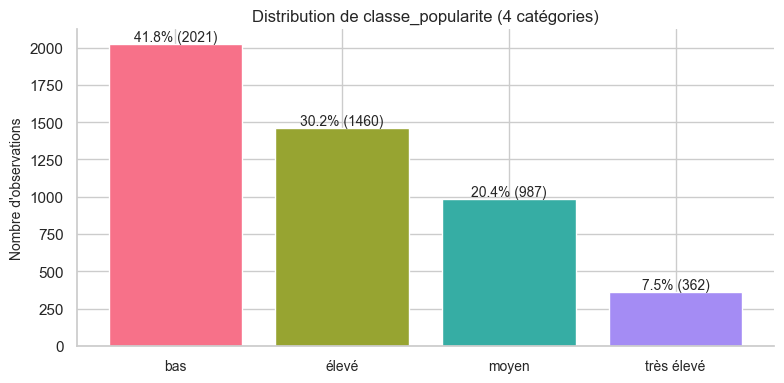

In [64]:
plot_categorical_distribution(df, "classe_popularite")


#### Interprétation de la variable cible `classe_popularite`

La variable `classe_popularite` présente une distribution déséquilibrée. Cette répartition indique que le dataset contient une proportion importante de morceaux peu populaires, ainsi qu’un second groupe significatif de morceaux à forte popularité. En revanche, les morceaux extrêmement populaires (`très élevé`) restent rares, ce qui reflète une réalité du marché musical où seuls quelques titres atteignent des niveaux de popularité très élevés.

Ce déséquilibre des classes est un point critique pour la modélisation. Il peut entraîner un biais du modèle en faveur des classes majoritaires, au détriment des classes minoritaires. C’est pourquoi l’utilisation de techniques adaptées, comme le paramètre `class_weight='balanced'`, est pertinente afin de compenser ce déséquilibre et améliorer la capacité du modèle à prédire correctement toutes les catégories.

<br>
<br>
<br>
<br>

## **6. Analyse des variables catégorielles (analyse univariée)**

L’analyse univariée des variables catégorielles vise à comprendre la répartition des différentes modalités présentes dans le dataset. Elle permet d’identifier les déséquilibres éventuels, la diversité des catégories et leur représentativité.

<br>
<br>

### **Objectifs de l’analyse**

- Identifier le nombre de catégories par variable
- Observer la distribution des fréquences (counts)
- Analyser les proportions (%) pour détecter les déséquilibres
- Repérer les catégories dominantes ou rares

<br>
<br>

### **Variables catégorielles étudiées**

- `genre_playlist`
- `sous_genre_playlist`
- `is_majeur_mineur`
- `signature_rythmique`

<br>
<br>


GENRE_PLAYLIST → 35 catégories
genre_playlist
electronic    589
pop           515
latin         425
hip-hop       395
ambient       359
rock          345
lofi          298
world         228
arabic        208
brazilian     148
jazz          146
gaming        133
classical     121
blues          88
afrobeats      82
wellness       80
punk           74
turkish        71
folk           68
indian         57
r&b            50
metal          49
soul           44
gospel         39
korean         34
funk           28
cantopop       27
reggae         24
j-pop          23
k-pop          17
indie          17
mandopop       14
soca           14
country        11
disco           9
Name: count, dtype: int64


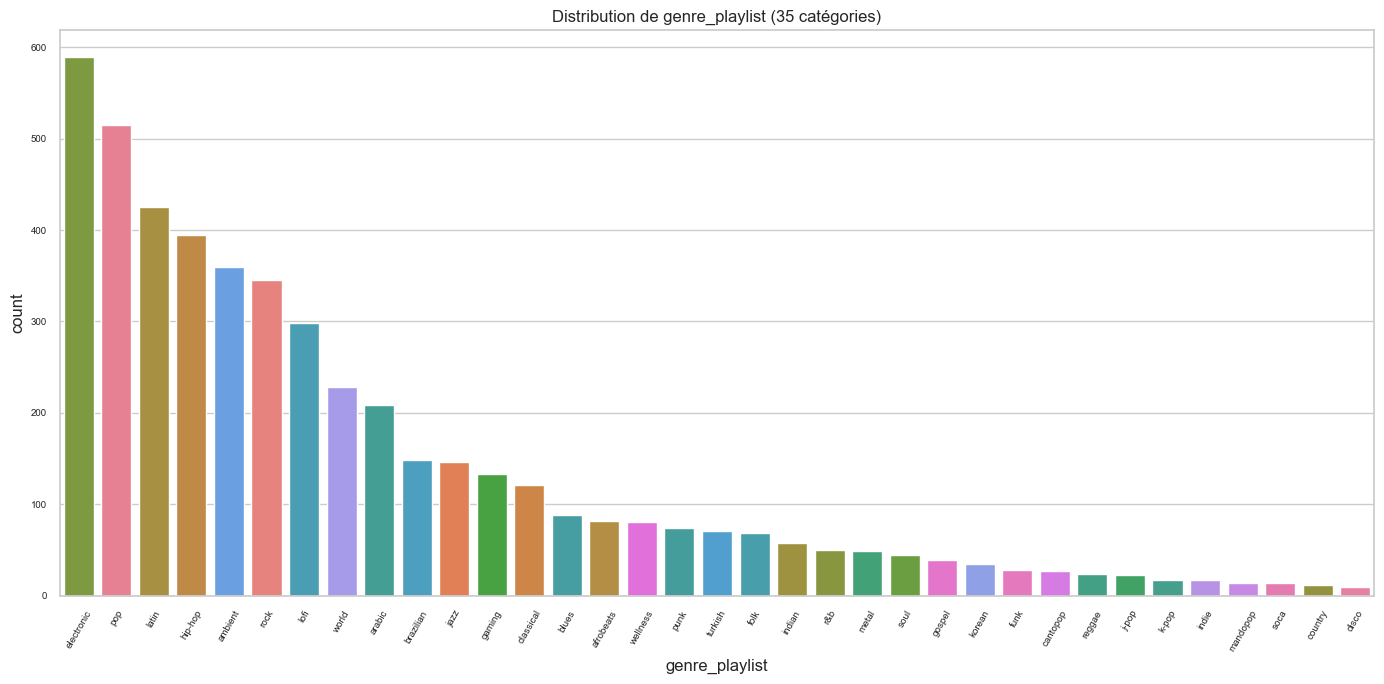

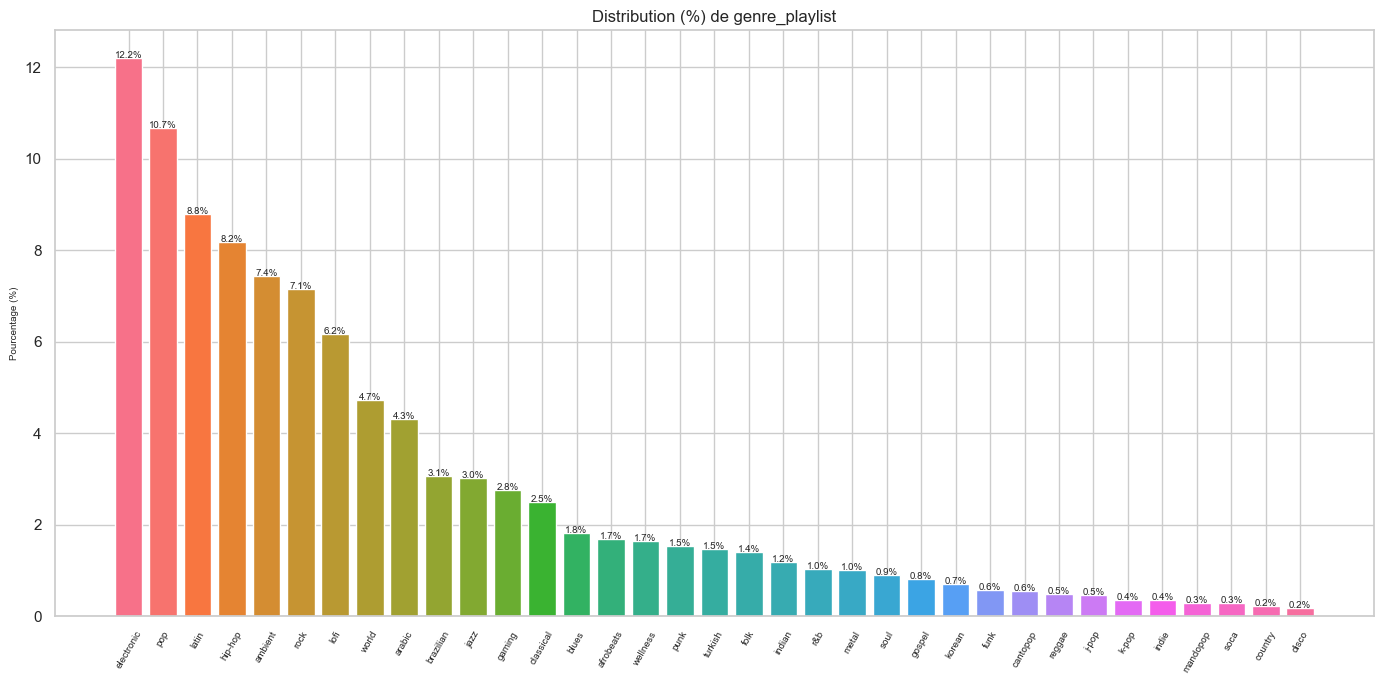

In [65]:

plot_categorical_distribution(df, "genre_playlist")





<br>
<br>
<br>
<br>


SOUS_GENRE_PLAYLIST → 84 catégories
sous_genre_playlist
modern         695
chill          419
classic        293
meditative     231
french         161
              ... 
noir             8
irish            6
heavy            5
post-rock        2
avant-garde      2
Name: count, Length: 84, dtype: int64


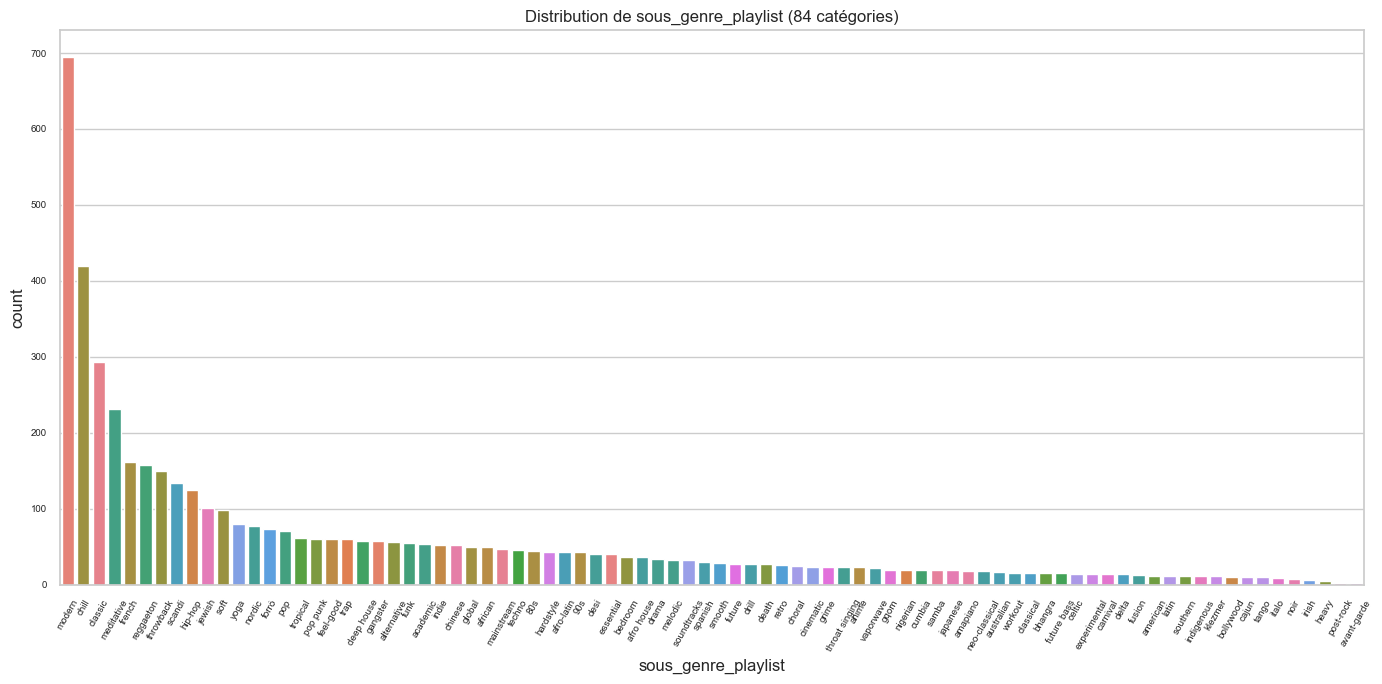

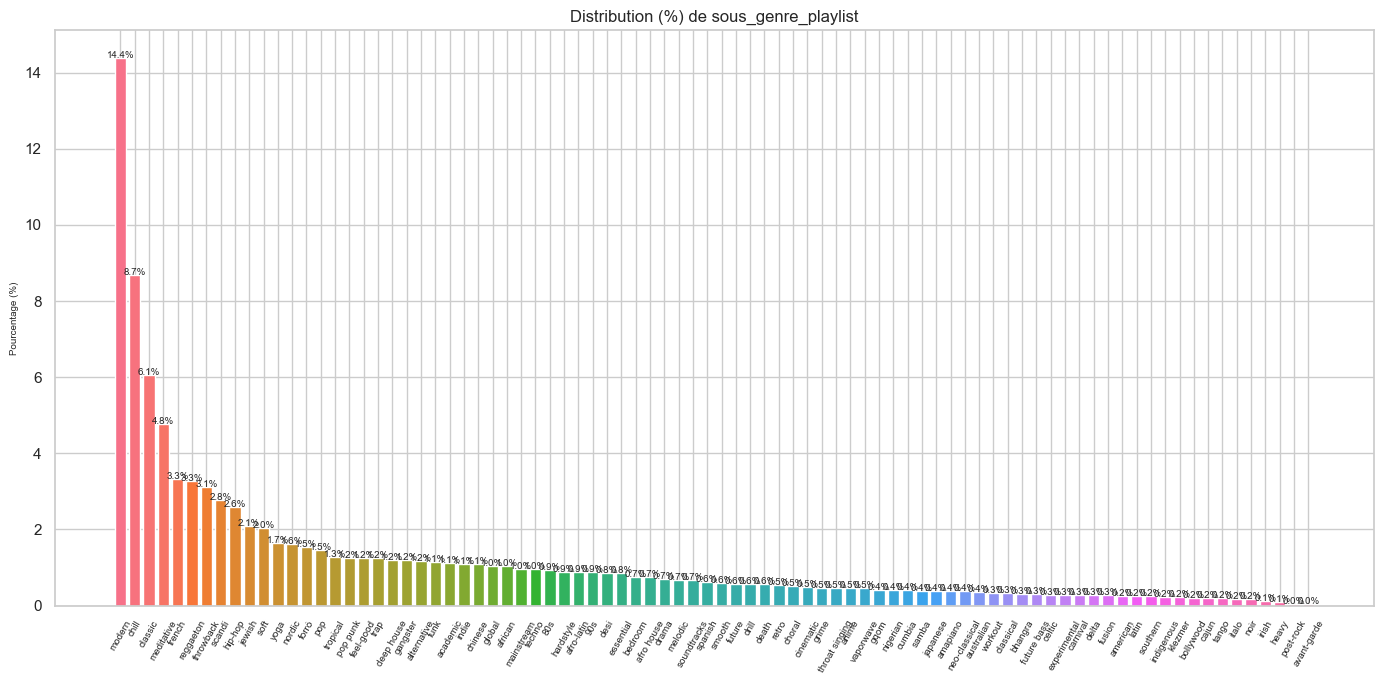

In [66]:

plot_categorical_distribution(df, "sous_genre_playlist")




<br>
<br>
<br>
<br>


IS_MAJEUR_MINEUR → 2 catégories
is_majeur_mineur
1.0    2715
0.0    2115
Name: count, dtype: int64


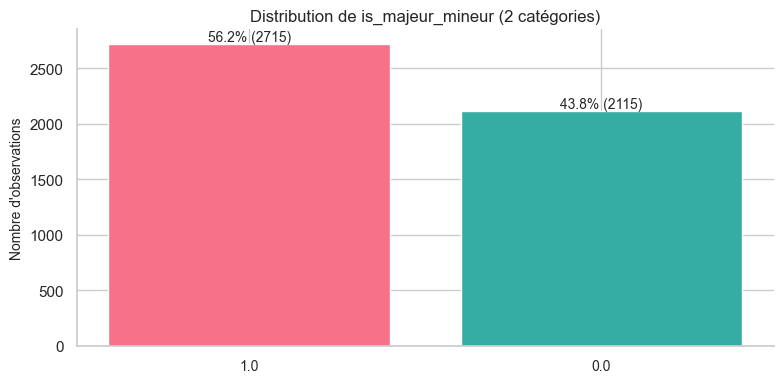

In [67]:

plot_categorical_distribution(df, "is_majeur_mineur")



<br>
<br>
<br>
<br>


SIGNATURE_RYTHMIQUE → 4 catégories
signature_rythmique
4.0    4296
3.0     346
5.0     151
1.0      37
Name: count, dtype: int64


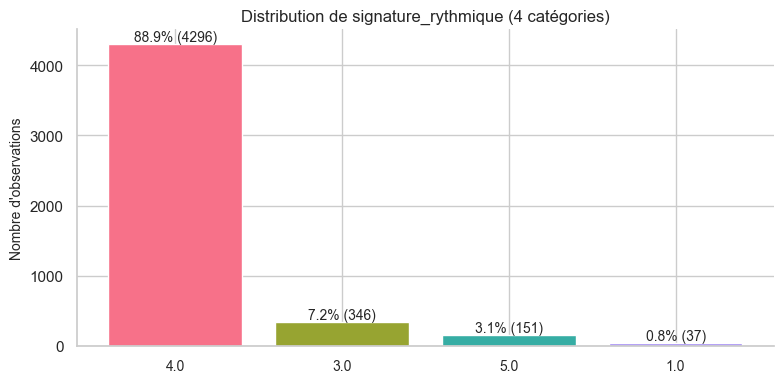

In [68]:

plot_categorical_distribution(df, "signature_rythmique")



L’analyse des variables catégorielles met en évidence une forte hétérogénéité du dataset, tant en termes de diversité que de répartition des modalités.

<br>

##### a) `genre_playlist`

La variable `genre_playlist` comporte **35 catégories**, avec une distribution très déséquilibrée. Les genres dominants sont `electronic`, `pop`, `latin` et `hip-hop`, qui concentrent une part importante des observations. À l’inverse, plusieurs genres comme `country`, `disco` ou `soca` sont très faiblement représentés.

Cela traduit une forte concentration des données sur certains styles musicaux populaires, ce qui peut introduire un biais dans le modèle, favorisant les genres majoritaires au détriment des genres minoritaires.

<br>

##### b)  `sous_genre_playlist`

Avec **84 catégories**, `sous_genre_playlist` est une variable très granulaire et fortement dispersée. Certaines modalités comme `modern`, `chill` ou `classic` dominent largement, tandis qu’un grand nombre de sous-genres sont très rares (moins de 10 occurrences).

Cette forte cardinalité peut poser des problèmes en modélisation, notamment avec le OneHotEncoding, en augmentant fortement la dimensionnalité. Elle peut nécessiter des regroupements ou une réduction de catégories.

<br>

##### c) `is_majeur_mineur`

La variable `is_majeur_mineur` présente seulement **2 catégories** (majeur vs mineur), avec une légère dominance du mode majeur (1.0). La distribution reste relativement équilibrée, ce qui en fait une variable stable et exploitable directement dans le modèle.

<br>

##### d) `signature_rythmique`

La signature rythmique est dominée très largement par le **4/4**, qui représente la quasi-totalité des morceaux. Les autres signatures (3/4, 5/4, etc.) sont marginales.

Cela reflète une standardisation forte de la structure rythmique dans la musique moderne. Cependant, cette variable apporte peu de variance, ce qui limite son pouvoir explicatif.

<br>


<br>
<br>
<br>
<br>

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# =========================
# Parsing date
# =========================
def parse_mixed_date(x):
    if pd.isna(x):
        return pd.NaT
    x = str(x)
    try:
        if "/" in x:
            return pd.to_datetime(x, format="%d/%m/%Y", errors="coerce")
        elif len(x) == 4:
            return pd.to_datetime(x, format="%Y", errors="coerce")
        elif len(x) == 7:
            return pd.to_datetime(x, format="%Y-%m", errors="coerce")
        else:
            return pd.to_datetime(x, format="%Y-%m-%d", errors="coerce")
    except:
        return pd.NaT


# =========================
# Fonction paramétrable
# =========================
def plot_time_distribution(
    df,
    date_col,
    freq="year",              # "month", "year", "3y", "5y", "10y"
    show_count_table=True,
    show_count_plot=True,
    show_percent_plot=True
):

    # =========================
    # Préparation
    # =========================
    df["_parsed"] = df[date_col].apply(parse_mixed_date)
    df["_year"] = df["_parsed"].dt.year
    df["_month"] = df["_parsed"].dt.to_period("M")

    # =========================
    # AGRÉGATION
    # =========================
    if freq == "month":
        data = df["_month"].value_counts().sort_index()
        labels = data.index.astype(str)

    elif freq == "year":
        data = df["_year"].value_counts().sort_index()
        labels = data.index.astype(int).astype(str)

    elif freq == "3y":
        df["_group"] = (df["_year"] // 3) * 3
        data = df["_group"].value_counts().sort_index()
        labels = data.index.astype(int).astype(str)

    elif freq == "5y":
        df["_group"] = (df["_year"] // 5) * 5
        data = df["_group"].value_counts().sort_index()
        labels = data.index.astype(int).astype(str)

    elif freq == "10y":
        df["_group"] = (df["_year"] // 10) * 10
        data = df["_group"].value_counts().sort_index()
        labels = data.index.astype(int).astype(str)

    else:
        raise ValueError("freq doit être: month, year, 3y, 5y, 10y")

    percent = data / data.sum() * 100
    n = len(data)

    # =========================
    # TABLE COUNT
    # =========================
    if show_count_table:
        print("\n" + "="*50)
        print(f"{date_col.upper()} → {freq} ({n} catégories)")
        print("="*50)
        print(data)

    # =========================
    # PARAM VISUELS
    # =========================
    fig_width = max(12, n * 0.4)
    colors = plt.cm.Set2(np.linspace(0, 1, n))
    step = max(1, n // 20)

    # =========================
    # GRAPH COUNT
    # =========================
    if show_count_plot:
        plt.figure(figsize=(fig_width, 6))

        plt.bar(labels, data.values, color=colors)

        plt.title(f"Distribution ({freq}) - Nombre", fontsize=12)
        plt.ylabel("Nombre")

        plt.xticks(np.arange(0, n, step), labels[::step], rotation=45)

        if n <= 25:
            for i, v in enumerate(data.values):
                plt.text(i, v, str(v), ha='center', fontsize=8)

        plt.subplots_adjust(bottom=0.25)
        plt.show()

    # =========================
    # GRAPH %
    # =========================
    if show_percent_plot:
        plt.figure(figsize=(fig_width, 6))

        plt.bar(labels, percent.values, color=colors)

        plt.title(f"Distribution ({freq}) - %", fontsize=12)
        plt.ylabel("Pourcentage (%)")

        plt.xticks(np.arange(0, n, step), labels[::step], rotation=45)

        if n <= 25:
            for i, v in enumerate(percent.values):
                plt.text(i, v, f"{v:.1f}%", ha='center', fontsize=8)

        plt.subplots_adjust(bottom=0.25)
        plt.show()

    # =========================
    # CLEAN
    # =========================
    df.drop(columns=["_parsed", "_year", "_month"], inplace=True, errors="ignore")
    if "_group" in df.columns:
        df.drop(columns=["_group"], inplace=True)






<br>
<br>
<br>
<br>


DATE_SORTIE_ALBUM → year (64 catégories)
_year
1954       1
1957       1
1962       1
1964       1
1965       1
        ... 
2020     275
2021     276
2022     408
2023     738
2024    1293
Name: count, Length: 64, dtype: int64


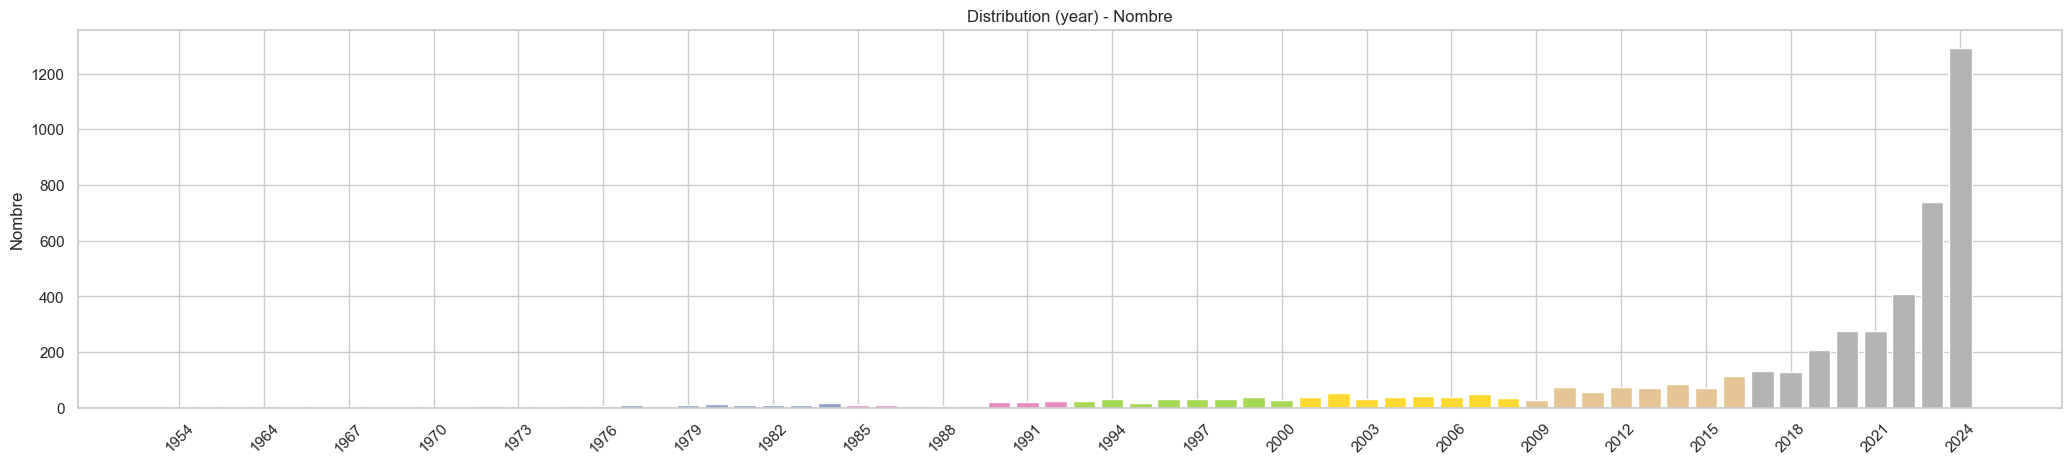

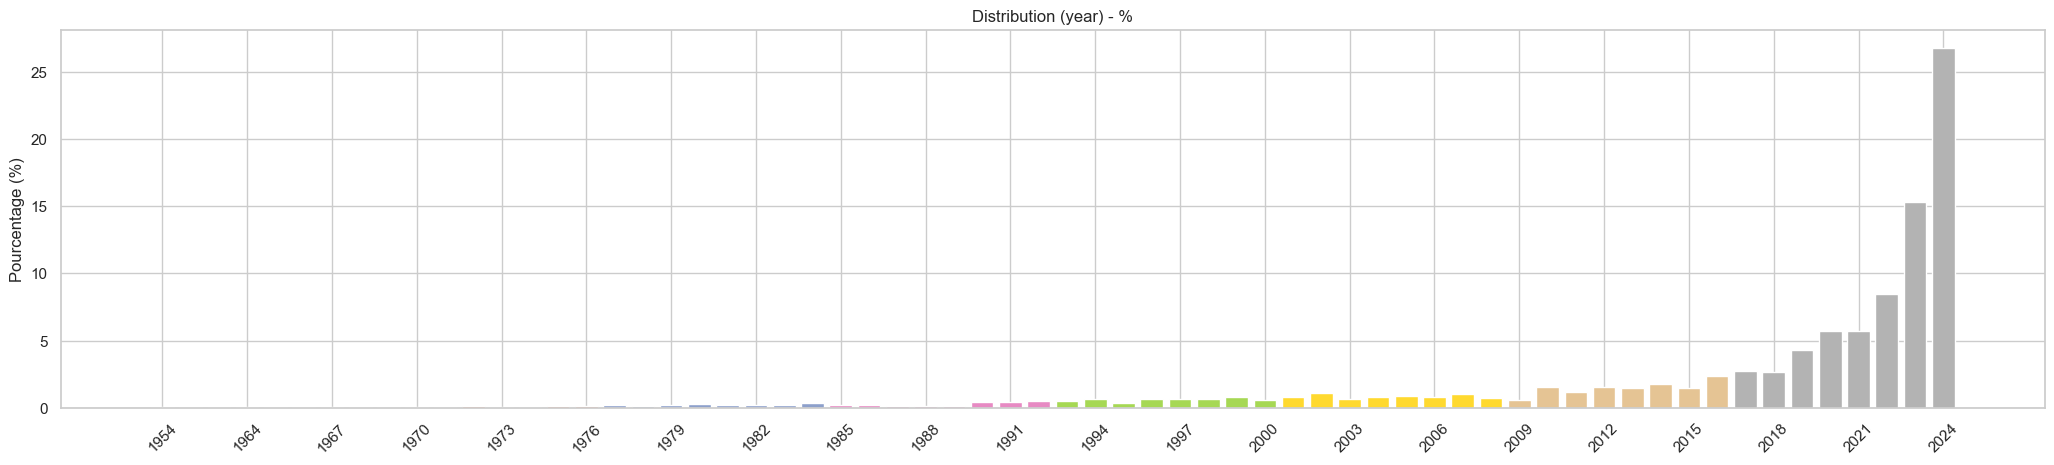

In [70]:

# Par année
plot_time_distribution(df, "date_sortie_album", freq="year")




<br>
<br>
<br>
<br>


DATE_SORTIE_ALBUM → 5y (15 catégories)
_group
1950       1
1955       1
1960       2
1965       7
1970      17
1975      39
1980      62
1985      41
1990     125
1995     148
2000     192
2005     191
2010     360
2015     654
2020    2990
Name: count, dtype: int64


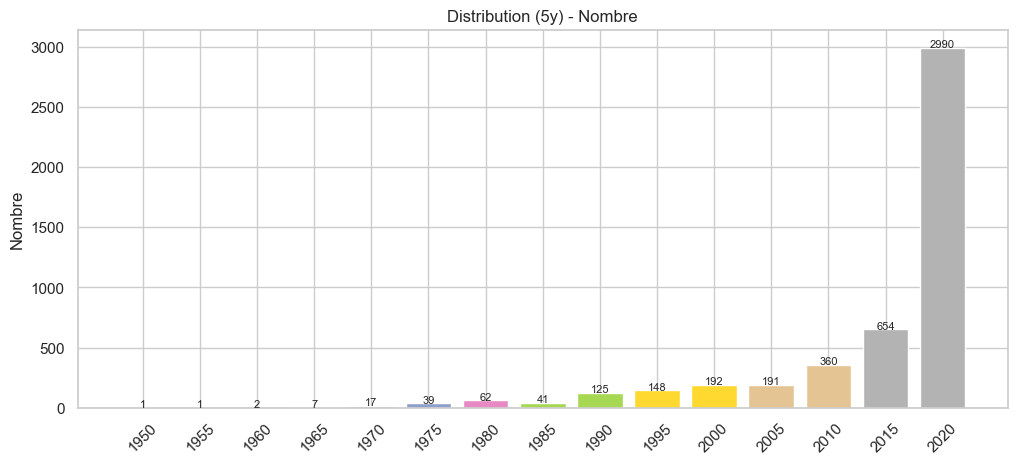

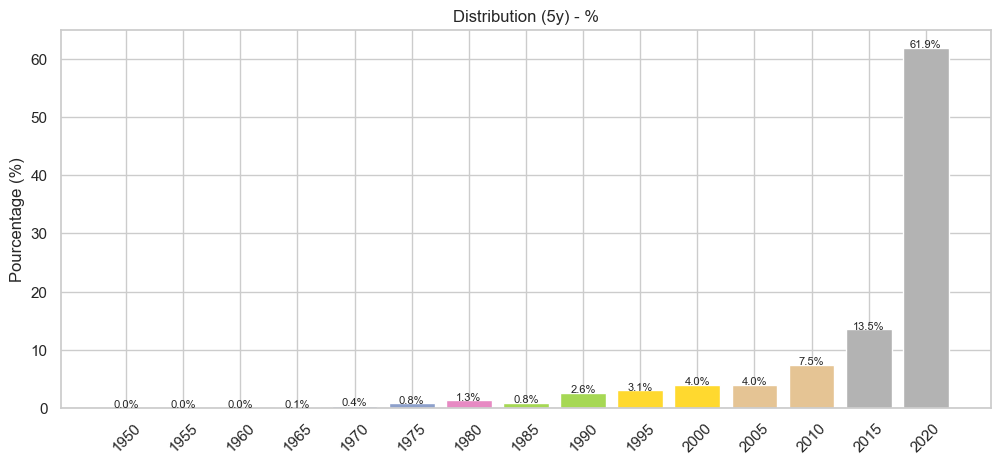

In [71]:


# Par tranche de 5 ans
plot_time_distribution(df, "date_sortie_album", freq="5y")




<br>
<br>
<br>
<br>


DATE_SORTIE_ALBUM → 10y (8 catégories)
_group
1950       2
1960       9
1970      56
1980     103
1990     273
2000     383
2010    1014
2020    2990
Name: count, dtype: int64


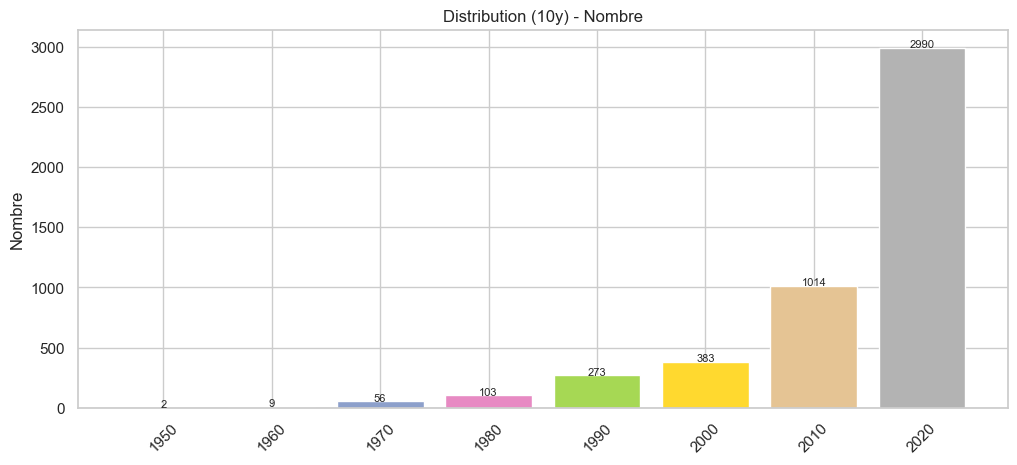

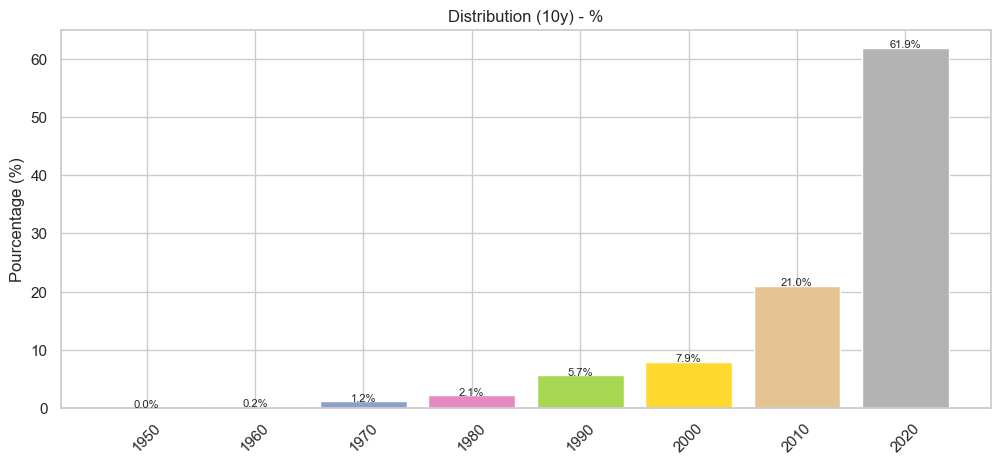

In [72]:

# Par décennie
plot_time_distribution(df, "date_sortie_album", freq="10y")



##### e) `date_sortie_album` (année brute)

La variable `date_sortie_album` couvre **64 années**, avec une forte concentration sur les années récentes, en particulier entre 2020 et 2024. Les années anciennes sont très peu représentées.

Cela montre un biais temporel du dataset vers la musique récente, ce qui est cohérent avec les usages actuels des plateformes de streaming.

<br>

##### f) agrégation temporelle (5 ans et 10 ans)

L’agrégation par périodes de **5 ans** et **10 ans** permet de mieux visualiser les tendances globales :

- Une croissance progressive du nombre de morceaux à partir des années 1990
- Une explosion très marquée à partir de 2010, et surtout après 2020
- Une concentration massive des données dans la décennie 2020

Ces transformations permettent de réduire la granularité et d’obtenir des variables plus stables pour la modélisation.

<br>


L’ensemble de ces analyses met en évidence :

- un **déséquilibre important** dans plusieurs variables catégorielles
- une **forte cardinalité** pour certaines variables (notamment `sous_genre_playlist`)
- une **dominance de certaines modalités** (genres, signatures rythmiques, années récentes)

Ces éléments doivent être pris en compte dans le processus de modélisation, notamment via des techniques d’encodage adaptées et, si nécessaire, des regroupements de catégories afin d’améliorer la robustesse et la performance du modèle.



<br>
<br>
<br>
<br>

#### Analyse des collaborations (feat)

L’analyse de la variable indiquant la présence de collaborations montre que **35 %** des morceaux comportent un featuring, contre **65 %** de morceaux solo. Les collaborations représentent donc une part significative du dataset, sans être majoritaires. Cette répartition relativement équilibrée permet d’intégrer cette variable comme facteur explicatif pertinent dans l’analyse de la popularité.
<br>
<br>


COLLABORATION → 2 catégories
collaboration
0    3150
1    1680
Name: count, dtype: int64


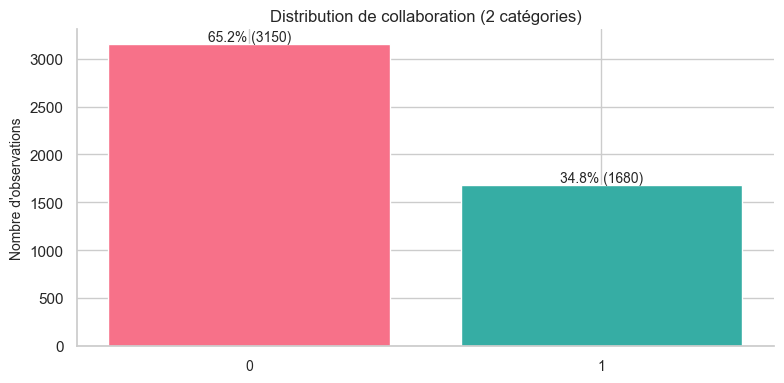

In [73]:
plot_categorical_distribution(df, "collaboration")




<br>
<br>
<br>
<br>

#### Nombre d’artistes par morceau

La distribution du nombre d’artistes révèle que la majorité des morceaux sont interprétés par un seul artiste (environ 65 %), suivis des duos (environ 24 %). Les collaborations impliquant trois artistes ou plus restent marginales. Cela indique que l’industrie musicale privilégie largement les productions solo ou en duo, tandis que les collaborations plus complexes sont rares.
<br>
<br>


NB_ARTISTES → 10 catégories
nb_artistes
1     3150
2     1150
3      333
4      116
5       47
6       20
8        6
9        4
7        3
20       1
Name: count, dtype: int64


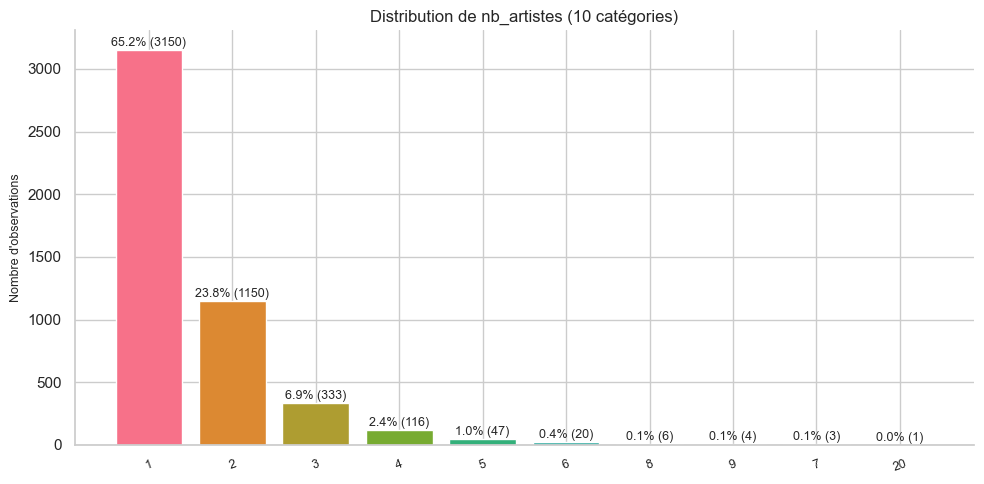

In [74]:
plot_categorical_distribution(df, "nb_artistes")




<br>
<br>
<br>
<br>

<br>
<br><br>
<br>

## **8. Analyse bivariée des variables**

L’analyse bivariée permet d’étudier les relations entre deux variables afin d’identifier des corrélations, des dépendances ou des effets explicatifs potentiels. Cette étape est essentielle pour comprendre quelles variables influencent la popularité des morceaux et orienter la modélisation.

<br>
<br>

##### **Objectifs de l’analyse**

- Identifier les relations entre variables (corrélation, dépendance)
- Détecter les variables explicatives importantes
- Comprendre les interactions entre variables numériques et catégorielles
- Visualiser les tendances et patterns
- Préparer la sélection de variables pour le modèle

<br>
<br>

##### **Types d’analyses réalisées**

<br>

###### **1. Numérique vs Numérique**

Analyse des relations entre variables quantitatives.

- `intensite_musicale` vs `niveau_sonore`
- `dansabilite` vs `tonalite_emotionnelle_positive`
- `battement_par_minute` vs `intensite_musicale`

**Méthodes utilisées :**

- Scatter plots (nuages de points)
- Corrélation (Pearson)
- Heatmap de corrélation

**Objectif :** détecter des relations linéaires ou non linéaires entre variables audio.

<br>

###### **2. Catégorielle vs Catégorielle**

Analyse des relations entre variables qualitatives.

- `genre_playlist` vs `sous_genre_playlist`
- `genre_playlist` vs `has_feat`

**Objectif :** comprendre la répartition des catégories et leurs associations.

<br>

###### **3. Numérique vs Catégorielle**

Analyse de l’impact des catégories sur des variables numériques.

- `track_popularity_score` vs `genre_playlist`
- `intensite_musicale` vs `genre_playlist`
- `dansabilite` vs `has_feat`


**Objectif :** analyser comment les caractéristiques musicales varient selon les catégories.

<br>
<br>

##### **Insights attendus**

- Identification des variables les plus corrélées entre elles
- Mise en évidence des variables influençant la popularité
- Détection de redondances (variables fortement corrélées)
- Compréhension des différences entre genres musicaux
- Aide à la sélection des variables pour la modélisation

<br>
<br>

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid")

# =========================
# Fonction analyse univariée numérique (PRO)
# =========================
def analyze_numeric_variable(
    df,
    col,
    show_boxplot=True,
    show_hist=True,
    show_density=True,
    bins="auto"
):

    series = df[col].dropna()

    # =========================
    # STATISTIQUES
    # =========================
    desc = series.describe()

    print("\n" + "="*60)
    print(f"{col.upper()} → Analyse univariée")
    print("="*60)
    print(desc)

    # stats supplémentaires
    skew = series.skew()
    kurt = series.kurt()

    print("\nSkewness :", round(skew, 3))
    print("Kurtosis :", round(kurt, 3))

    # =========================
    # OUTLIERS (IQR)
    # =========================
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((series < lower) | (series > upper)).sum()
    print("Outliers (IQR) :", outliers)

    # =========================
    # ADAPTATION FIGURE
    # =========================
    figsize = (10, 5)

    # =========================
    # HISTOGRAMME + DENSITÉ
    # =========================
    if show_hist:

        plt.figure(figsize=figsize)

        sns.histplot(
            series,
            bins=bins,
            kde=show_density
        )

        plt.title(f"Distribution de {col}", fontsize=12)
        plt.xlabel(col)
        plt.ylabel("Fréquence")

        plt.tight_layout()
        plt.show()

    # =========================
    # BOXPLOT (OUTLIERS)
    # =========================
    if show_boxplot:

        plt.figure(figsize=(8, 4))

        sns.boxplot(x=series)

        plt.title(f"Boxplot de {col}", fontsize=12)

        plt.tight_layout()
        plt.show()





<br>
<br>

<br>
<br>



################################################################################
ANALYSE VARIABLE 1/11 → INTENSITE_MUSICALE
################################################################################

INTENSITE_MUSICALE → Analyse univariée
count    4830.000000
mean        0.586691
std         0.246263
min         0.000202
25%         0.442250
50%         0.633000
75%         0.777000
max         0.998000
Name: intensite_musicale, dtype: float64

Skewness : -0.689
Kurtosis : -0.259
Outliers (IQR) : 0


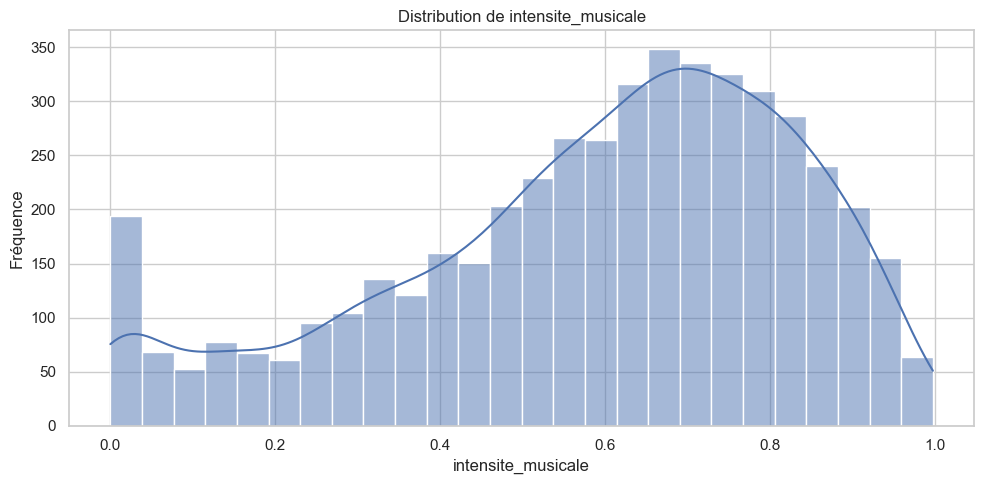

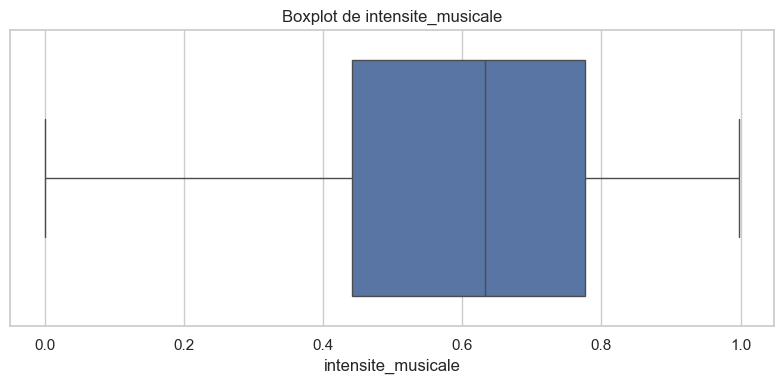

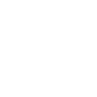


################################################################################
ANALYSE VARIABLE 2/11 → BATTEMENT_PAR_MINUTE
################################################################################

BATTEMENT_PAR_MINUTE → Analyse univariée
count    4830.000000
mean      118.269293
std        28.512615
min        48.232000
25%        96.063000
50%       118.059500
75%       136.723500
max       241.426000
Name: battement_par_minute, dtype: float64

Skewness : 0.357
Kurtosis : -0.193
Outliers (IQR) : 20


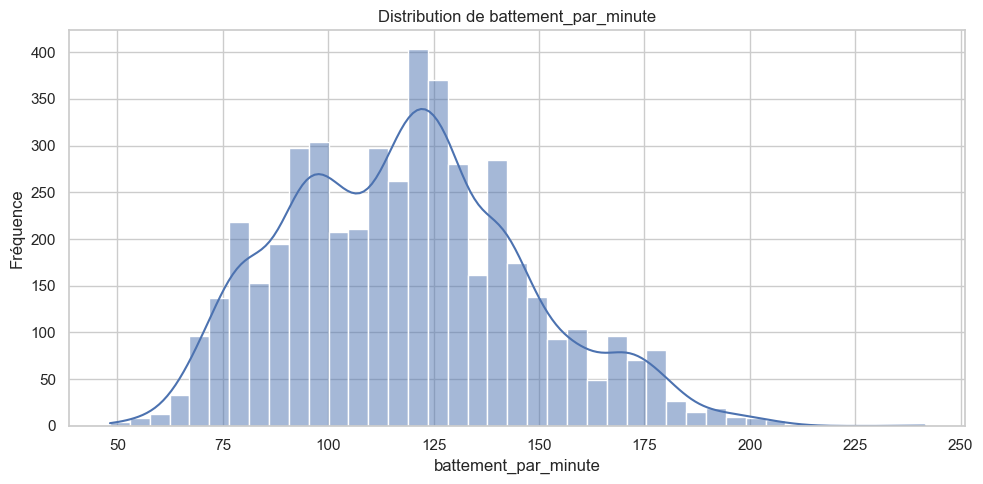

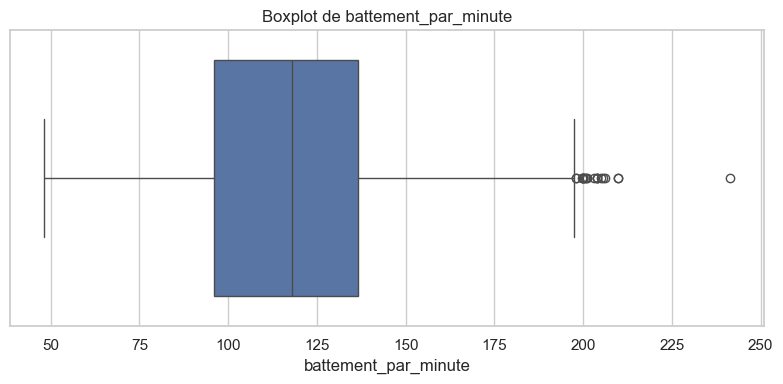

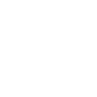


################################################################################
ANALYSE VARIABLE 3/11 → DANSABILITE
################################################################################

DANSABILITE → Analyse univariée
count    4830.000000
mean        0.622311
std         0.187706
min         0.058900
25%         0.525000
50%         0.653000
75%         0.758000
max         0.979000
Name: dansabilite, dtype: float64

Skewness : -0.836
Kurtosis : 0.383
Outliers (IQR) : 191


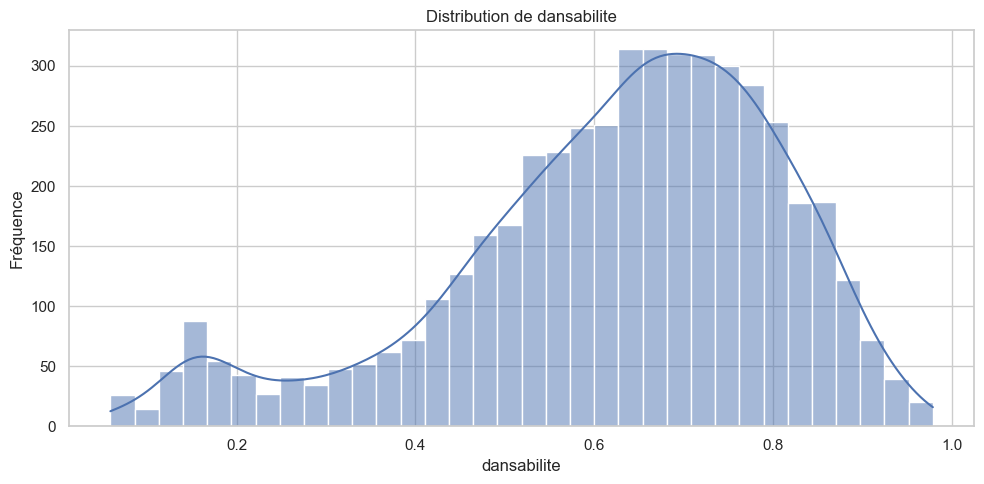

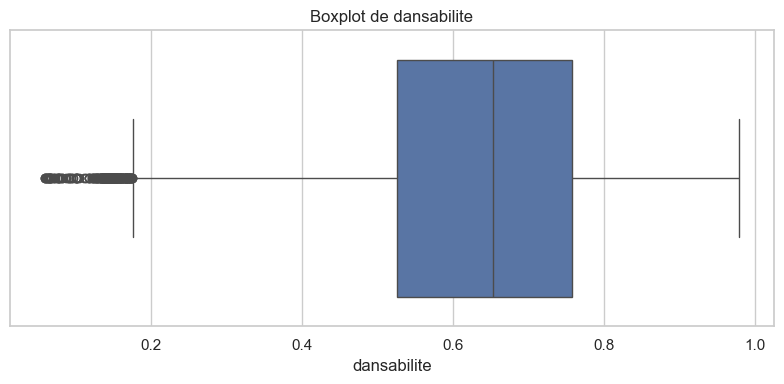

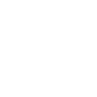


################################################################################
ANALYSE VARIABLE 4/11 → NIVEAU_SONORE
################################################################################

NIVEAU_SONORE → Analyse univariée
count    4830.000000
mean       -9.281627
std         7.129396
min       -48.069000
25%       -10.297750
50%        -7.191000
75%        -5.336750
max         1.318000
Name: niveau_sonore, dtype: float64

Skewness : -2.683
Kurtosis : 8.135
Outliers (IQR) : 403


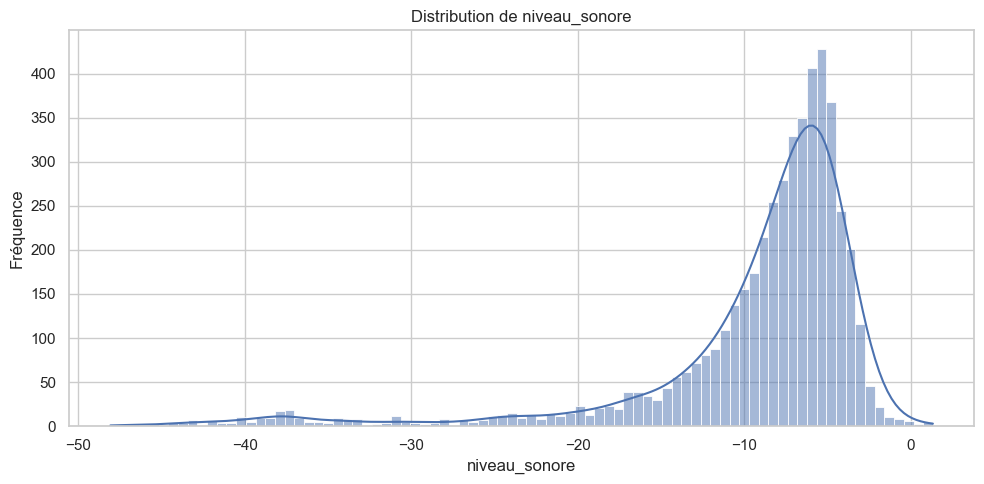

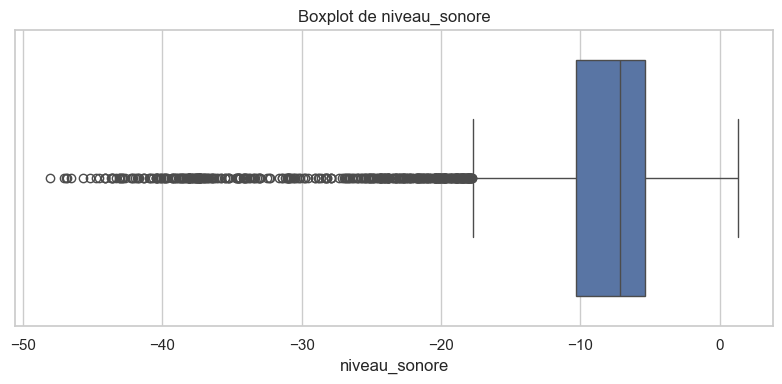

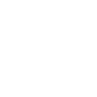


################################################################################
ANALYSE VARIABLE 5/11 → PROBABILITE_IS_LIVE
################################################################################

PROBABILITE_IS_LIVE → Analyse univariée
count    4830.000000
mean        0.167613
std         0.124429
min         0.021000
25%         0.095400
50%         0.118000
75%         0.195000
max         0.979000
Name: probabilite_is_live, dtype: float64

Skewness : 2.357
Kurtosis : 7.143
Outliers (IQR) : 425


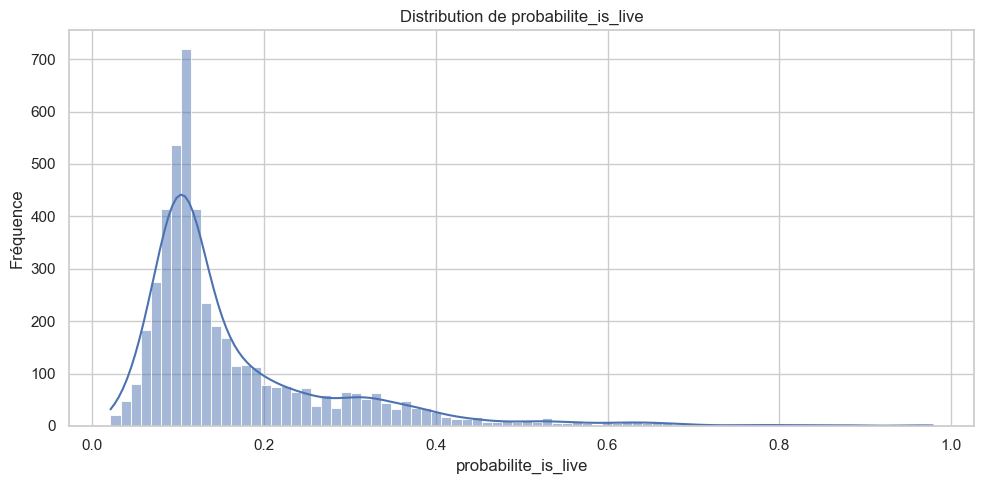

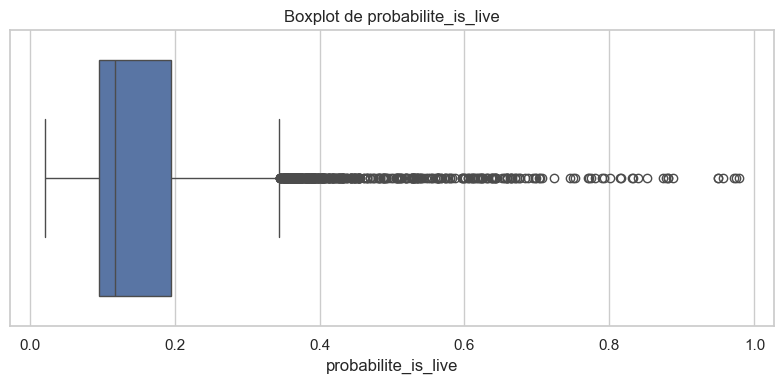

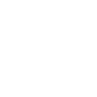


################################################################################
ANALYSE VARIABLE 6/11 → TONALITE_EMOTIONNELLE_POSITIVE
################################################################################

TONALITE_EMOTIONNELLE_POSITIVE → Analyse univariée
count    4830.000000
mean        0.481930
std         0.258036
min         0.029600
25%         0.275000
50%         0.483000
75%         0.690000
max         0.987000
Name: tonalite_emotionnelle_positive, dtype: float64

Skewness : -0.003
Kurtosis : -1.02
Outliers (IQR) : 0


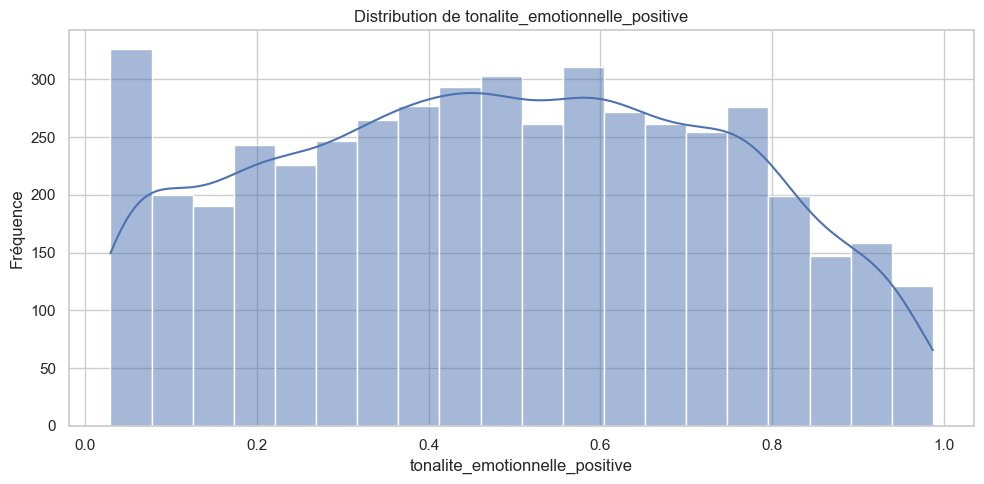

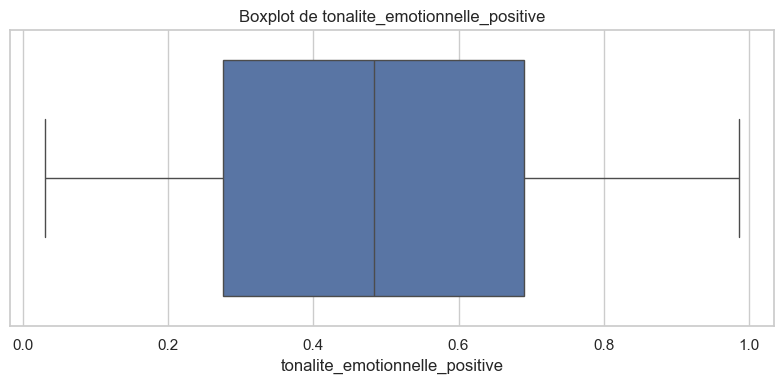

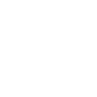


################################################################################
ANALYSE VARIABLE 7/11 → PRESENCE_PAROLE
################################################################################

PRESENCE_PAROLE → Analyse univariée
count    4830.000000
mean        0.101738
std         0.101032
min         0.021900
25%         0.038600
50%         0.056100
75%         0.118000
max         0.927000
Name: presence_parole, dtype: float64

Skewness : 2.057
Kurtosis : 4.662
Outliers (IQR) : 590


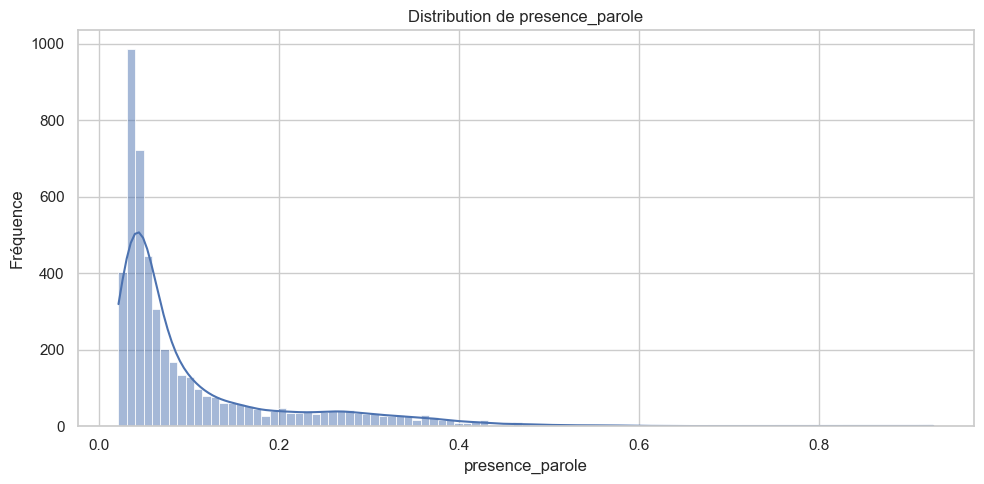

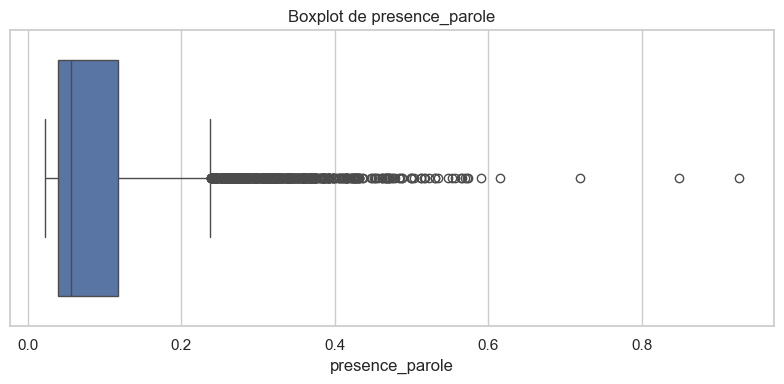

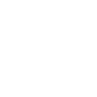


################################################################################
ANALYSE VARIABLE 8/11 → PROBABILITE_ISONLY_INSTRUMENTAL
################################################################################

PROBABILITE_ISONLY_INSTRUMENTAL → Analyse univariée
count    4830.000000
mean        0.201053
std         0.351918
min         0.000000
25%         0.000000
50%         0.000091
75%         0.200500
max         0.991000
Name: probabilite_isonly_instrumental, dtype: float64

Skewness : 1.35
Kurtosis : -0.021
Outliers (IQR) : 1039


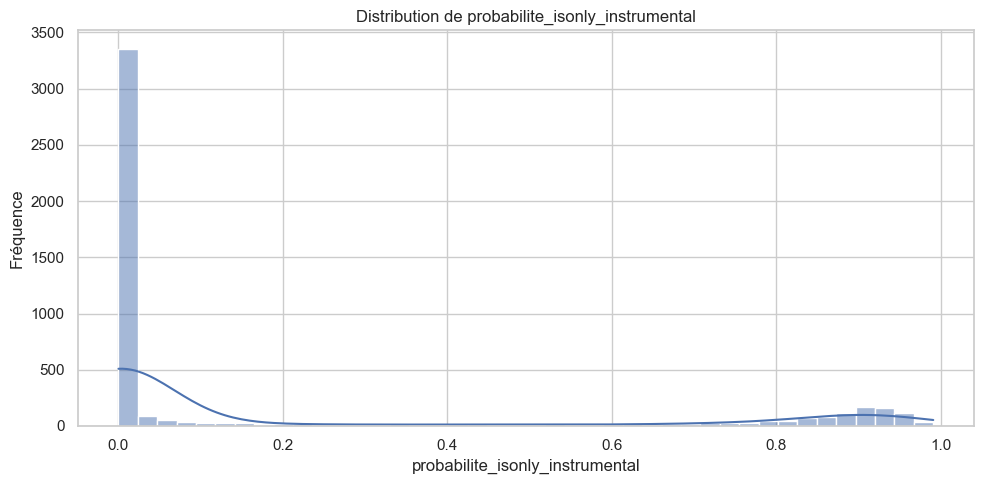

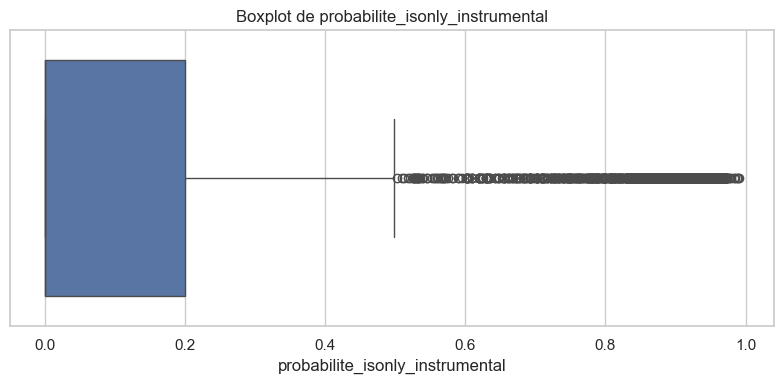

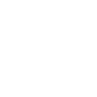


################################################################################
ANALYSE VARIABLE 9/11 → TONALITE
################################################################################

TONALITE → Analyse univariée
count    4830.000000
mean        5.233333
std         3.580857
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        11.000000
Name: tonalite, dtype: float64

Skewness : 0.049
Kurtosis : -1.288
Outliers (IQR) : 0


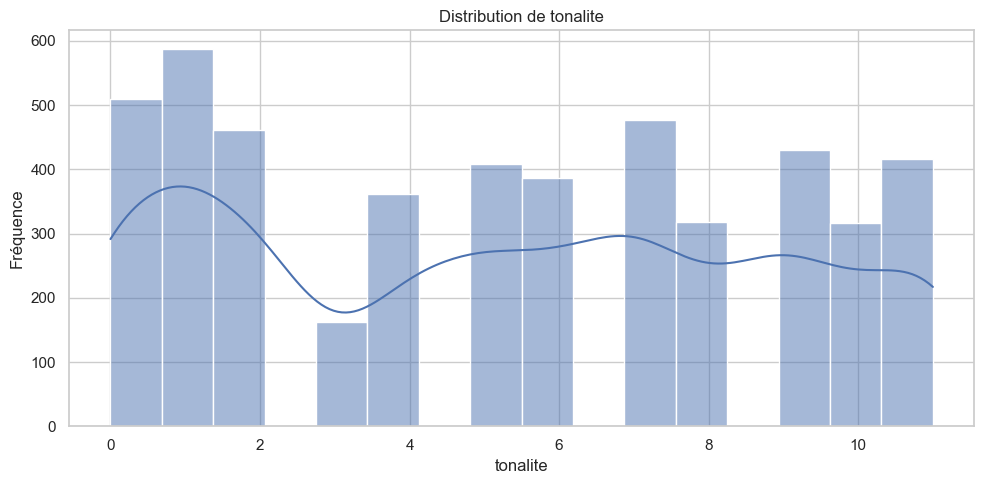

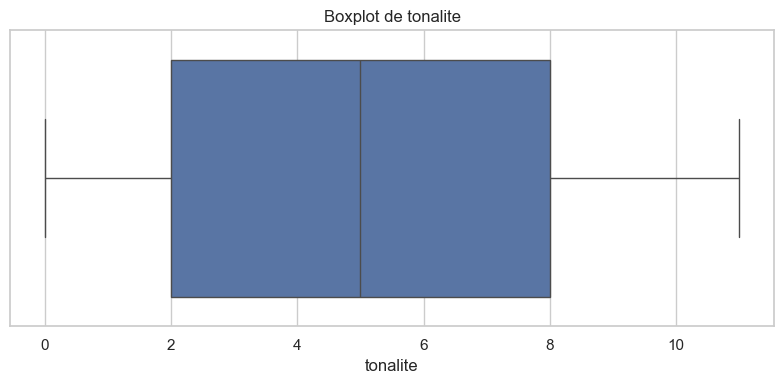

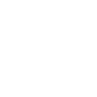


################################################################################
ANALYSE VARIABLE 10/11 → DUREE_MS
################################################################################

DUREE_MS → Analyse univariée
count    4.830000e+03
mean     2.061508e+05
std      8.174556e+04
min      3.537500e+04
25%      1.590000e+05
50%      1.948665e+05
75%      2.334780e+05
max      1.355260e+06
Name: duree_ms, dtype: float64

Skewness : 3.985
Kurtosis : 33.436
Outliers (IQR) : 190


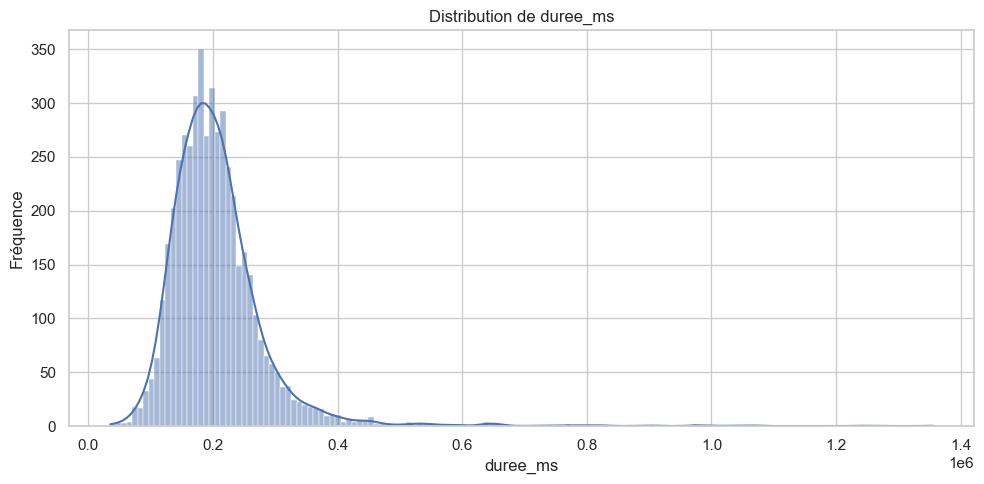

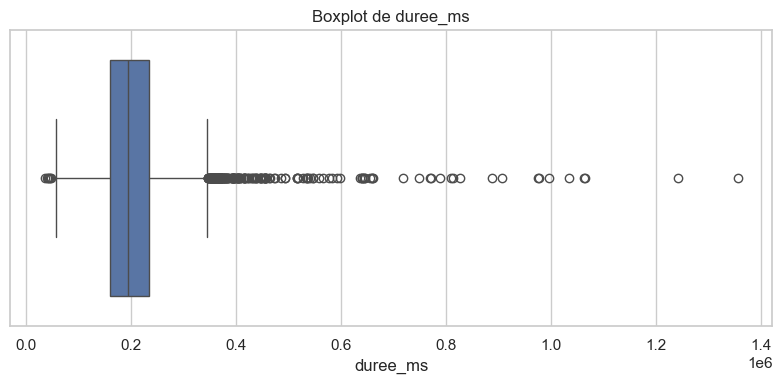

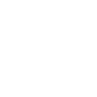


################################################################################
ANALYSE VARIABLE 11/11 → PROBABILITE_IS_ACOUSTIQUE
################################################################################

PROBABILITE_IS_ACOUSTIQUE → Analyse univariée
count    4830.000000
mean        0.341217
std         0.325382
min         0.000004
25%         0.052925
50%         0.224500
75%         0.590000
max         0.996000
Name: probabilite_is_acoustique, dtype: float64

Skewness : 0.704
Kurtosis : -0.903
Outliers (IQR) : 0


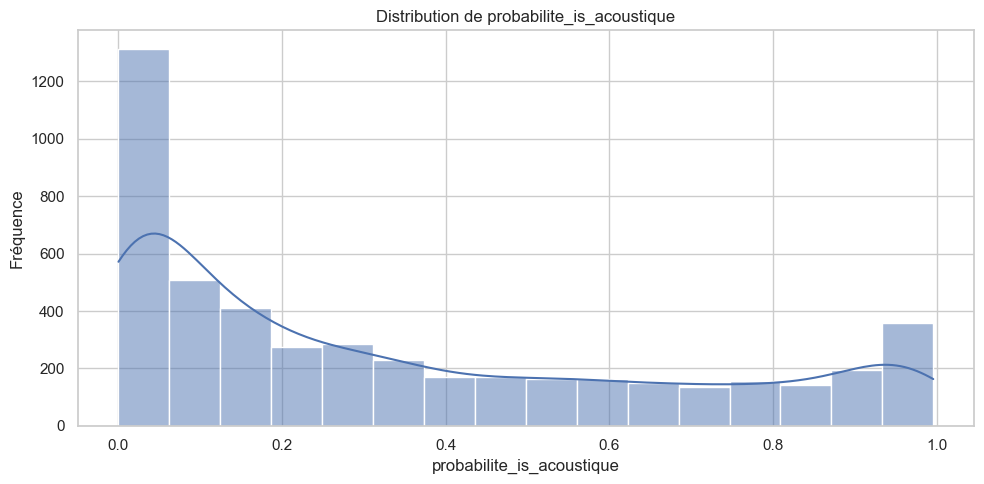

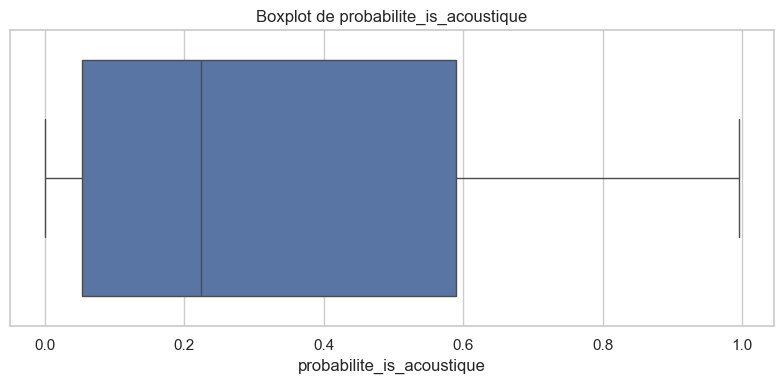

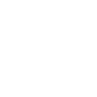

In [76]:
num_cols = [
    "intensite_musicale",
    "battement_par_minute",
    "dansabilite",
    "niveau_sonore",
    "probabilite_is_live",
    "tonalite_emotionnelle_positive",
    "presence_parole",
    "probabilite_isonly_instrumental",
    "tonalite",
    "duree_ms",
    "probabilite_is_acoustique"
]

for i, col in enumerate(num_cols):

    print("\n" + "#"*80)
    print(f"ANALYSE VARIABLE {i+1}/{len(num_cols)} → {col.upper()}")
    print("#"*80)

    analyze_numeric_variable(df, col)

    # séparation visuelle notebook
    plt.figure(figsize=(1,1))
    plt.axis('off')
    plt.show()

Cette analyse montre que les caractéristiques audio des morceaux sont très hétérogènes. La présence d’asymétries et d’outliers justifie l’utilisation de techniques de preprocessing adaptées (normalisation, robust scaling ou transformation logarithmique) afin d’améliorer la stabilité et la performance des modèles de Machine Learning.

<br>

#### **Variables équilibrées et bien distribuées**

- **`tonalite_emotionnelle_positive`** présente une distribution quasi symétrique (skewness ≈ 0) sans outliers. Cela indique une bonne répartition des émotions musicales, allant de morceaux tristes à joyeux.
- **`intensite_musicale`** et **`dansabilite`** sont légèrement asymétriques à gauche, ce qui signifie que les morceaux sont globalement assez dynamiques et dansants. Ces variables sont relativement concentrées, avec peu ou pas d’outliers pour `intensite_musicale`.

<br>

#### **Variables modérément dispersées**

- **`battement_par_minute`** montre une distribution relativement équilibrée, centrée autour de 118 BPM, avec quelques valeurs extrêmes mais limitées.
- **`probabilite_is_acoustique`** présente une légère asymétrie positive, traduisant une diversité entre morceaux acoustiques et électroniques.
- **`tonalite`** est uniformément répartie, ce qui est cohérent avec une distribution musicale variée des tonalités.

<br>

#### **Variables fortement asymétriques**

- **`probabilite_is_live`** et **`presence_parole`** présentent une forte asymétrie positive, indiquant que la majorité des morceaux ont peu de caractéristiques live ou parlées, avec quelques valeurs élevées (concerts, rap, discours).
- **`probabilite_isonly_instrumental`** est fortement concentrée vers 0, ce qui montre que la plupart des morceaux contiennent des voix, tandis qu’une minorité est purement instrumentale.

<br>

#### **Variables avec forte présence d’outliers**

- **`niveau_sonore`** présente une forte asymétrie négative et de nombreux outliers. Cela reflète une grande variabilité dans le volume sonore, notamment entre morceaux anciens, live ou peu produits.
- **`duree_ms`** est très asymétrique (skewness élevée) avec une kurtosis importante, indiquant la présence de morceaux très longs (outliers). La majorité des morceaux reste toutefois concentrée autour de 3 à 4 minutes.

<br>

#### **Synthèse**

- Certaines variables sont **bien distribuées et exploitables directement** (`tonalite_emotionnelle_positive`, `intensite_musicale`)
- D’autres présentent des **asymétries importantes** nécessitant éventuellement des transformations (`duree_ms`, `presence_parole`, `probabilite_isonly_instrumental`)
- Plusieurs variables contiennent des **outliers significatifs**, ce qui peut impacter certains modèles

<br>

<br><br><br><br>

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency, pearsonr, f_oneway

sns.set(style="whitegrid")

def analyse_bivariee(df, var1, var2, type_analyse):

    print("\n" + "="*70)
    print(f"Analyse bivariée ({type_analyse}) : {var1} vs {var2}")
    print("="*70)

    # =========================
    # 1. NUM vs NUM
    # =========================
    if type_analyse == "num-num":

        data = df[[var1, var2]].dropna()
        corr, p_value = pearsonr(data[var1], data[var2])

        print(f"Corrélation (Pearson) : {corr:.3f}")
        print(f"P-value : {p_value:.5f}")

        plt.figure(figsize=(6,4))
        sns.scatterplot(data=data, x=var1, y=var2, alpha=0.3)
        sns.regplot(data=data, x=var1, y=var2, scatter=False, color="red")
        plt.title(f"{var1} vs {var2}")
        plt.tight_layout()
        plt.show()

    # =========================
    # 2. CAT vs CAT
    # =========================
    elif type_analyse == "cat-cat":

        contingency = pd.crosstab(df[var1], df[var2])
        chi2, p, dof, _ = chi2_contingency(contingency)

        print("Table de contingence :")
        print(contingency)

        print(f"\nChi2 : {chi2:.2f}")
        print(f"P-value : {p:.5f}")

        plt.figure(figsize=(8,5))
        contingency.plot(kind="bar", stacked=True)
        plt.title(f"{var1} vs {var2}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # =========================
    # 3. NUM vs CAT
    # =========================
    elif type_analyse == "num-cat":

        num_var = var1
        cat_var = var2

        print(f"{num_var} selon {cat_var}")

        grouped = df.groupby(cat_var)[num_var].describe()[["mean", "std", "min", "max"]]
        print(grouped)

        # ANOVA
        groups = [g.dropna().values for _, g in df.groupby(cat_var)[num_var]]
        if len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            print(f"\nANOVA F-stat : {f_stat:.2f}")
            print(f"P-value : {p_val:.5f}")

        plt.figure(figsize=(8,5))
        sns.boxplot(data=df, x=cat_var, y=num_var)
        plt.title(f"{num_var} par {cat_var}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # =========================
    # 4. CAT vs NUM (inverse)
    # =========================
    elif type_analyse == "cat-num":
        analyse_bivariee(df, var2, var1, "num-cat")

    else:
        print("Type invalide. Utiliser : num-num, cat-cat, num-cat, cat-num")


Analyse bivariée (num-num) : intensite_musicale vs niveau_sonore
Corrélation (Pearson) : 0.799
P-value : 0.00000


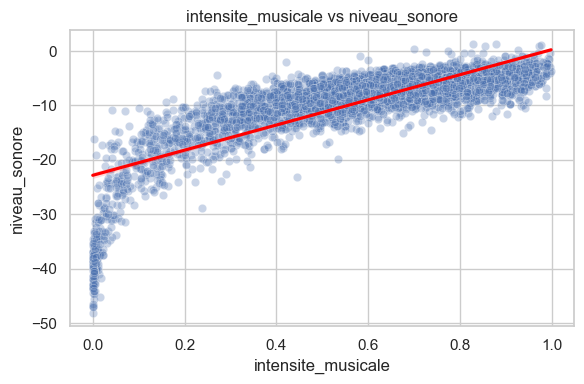


Analyse bivariée (num-num) : dansabilite vs tonalite_emotionnelle_positive
Corrélation (Pearson) : 0.514
P-value : 0.00000


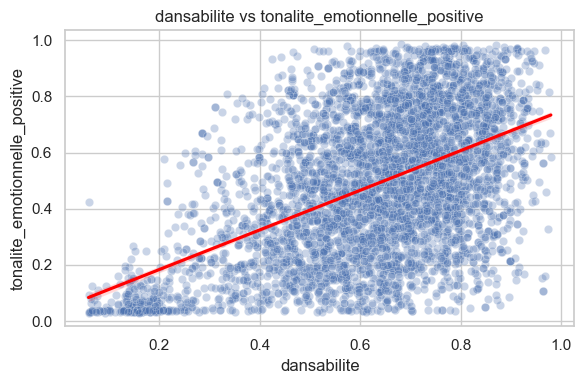


Analyse bivariée (num-num) : battement_par_minute vs intensite_musicale
Corrélation (Pearson) : 0.198
P-value : 0.00000


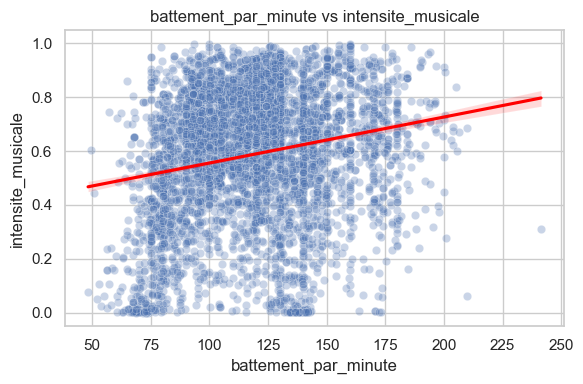

In [78]:
analyse_bivariee(df, "intensite_musicale", "niveau_sonore", "num-num")
analyse_bivariee(df, "dansabilite", "tonalite_emotionnelle_positive", "num-num")
analyse_bivariee(df, "battement_par_minute", "intensite_musicale", "num-num")



Analyse bivariée (cat-cat) : genre_playlist vs collaboration
Table de contingence :
collaboration     0    1
genre_playlist          
afrobeats        24   58
ambient         235  124
arabic          121   87
blues            68   20
brazilian        81   67
cantopop         26    1
classical        40   81
country          10    1
disco             8    1
electronic      289  300
folk             56   12
funk             20    8
gaming           77   56
gospel           22   17
hip-hop         215  180
indian            8   49
indie            17    0
j-pop            19    4
jazz             85   61
k-pop            15    2
korean           27    7
latin           212  213
lofi            253   45
mandopop         10    4
metal            47    2
pop             383  132
punk             72    2
r&b              34   16
reggae           14   10
rock            329   16
soca             10    4
soul             31   13
turkish          47   24
wellness         79    1
world          

<Figure size 800x500 with 0 Axes>

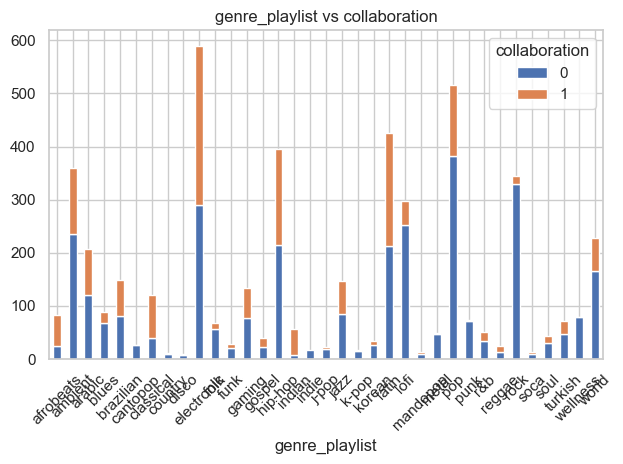


Analyse bivariée (cat-cat) : sous_genre_playlist vs collaboration
Table de contingence :
collaboration         0   1
sous_genre_playlist        
80s                  43   2
90s                  29  14
academic             50   4
african              20  30
afro house            5  31
...                  ..  ..
trap                 17  43
tropical             20  42
vaporwave            16   6
workout               0  16
yoga                 79   1

[84 rows x 2 columns]

Chi2 : 1098.57
P-value : 0.00000


<Figure size 800x500 with 0 Axes>

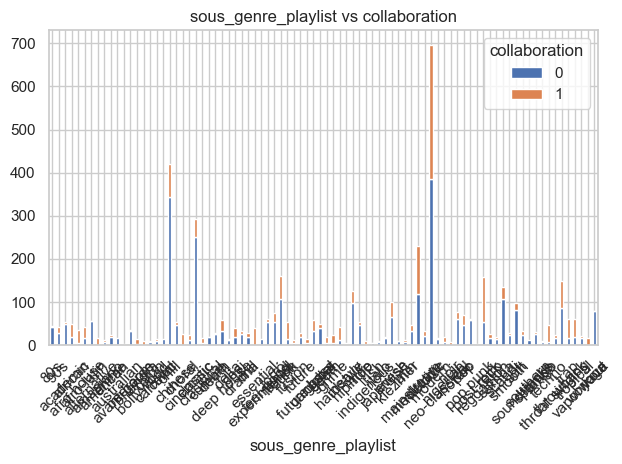

In [79]:

analyse_bivariee(df, "genre_playlist", "collaboration", "cat-cat")
analyse_bivariee(df, "sous_genre_playlist", "collaboration", "cat-cat")





Analyse bivariée (num-cat) : popularite_morceau vs genre_playlist
popularite_morceau selon genre_playlist
                     mean        std   min    max
genre_playlist                                   
afrobeats       52.573171  18.252029  11.0   78.0
ambient         49.991643  16.058289  14.0   88.0
arabic          51.475962  16.239137  12.0   88.0
blues           59.886364  18.228077  18.0   83.0
brazilian       39.689189  18.420948  12.0   78.0
cantopop        24.592593   7.923962  11.0   39.0
classical       46.793388  14.006497  18.0   75.0
country         48.454545  16.907771  25.0   73.0
disco           24.000000  12.668859  13.0   52.0
electronic      52.937182  18.020523  11.0   86.0
folk            59.588235  19.138330  14.0   93.0
funk            32.178571   6.481047  20.0   51.0
gaming          70.736842  18.575764  20.0  100.0
gospel          47.051282   8.999850  28.0   59.0
hip-hop         63.496203  17.566895  11.0   92.0
indian          45.456140  20.566156  13.0 

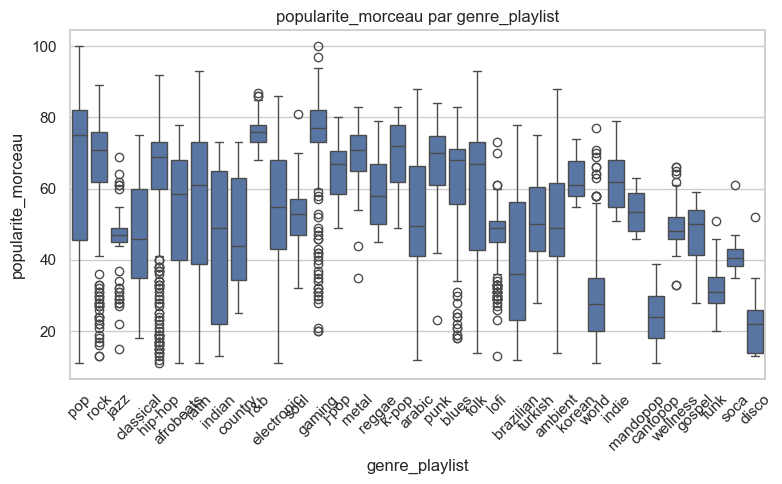


Analyse bivariée (num-cat) : intensite_musicale vs genre_playlist
intensite_musicale selon genre_playlist
                    mean       std       min    max
genre_playlist                                     
afrobeats       0.691159  0.143811  0.180000  0.987
ambient         0.465437  0.282640  0.000202  0.919
arabic          0.637058  0.160383  0.148000  0.960
blues           0.504650  0.184142  0.070200  0.932
brazilian       0.688507  0.165154  0.285000  0.990
cantopop        0.478519  0.185026  0.200000  0.893
classical       0.195210  0.230552  0.003620  0.906
country         0.465455  0.121650  0.336000  0.688
disco           0.680333  0.196259  0.331000  0.956
electronic      0.640950  0.250334  0.009450  0.998
folk            0.431525  0.197218  0.069700  0.928
funk            0.808714  0.121371  0.553000  0.947
gaming          0.634233  0.209590  0.002290  0.967
gospel          0.717205  0.136455  0.477000  0.941
hip-hop         0.643734  0.133486  0.251000  0.946
indian   

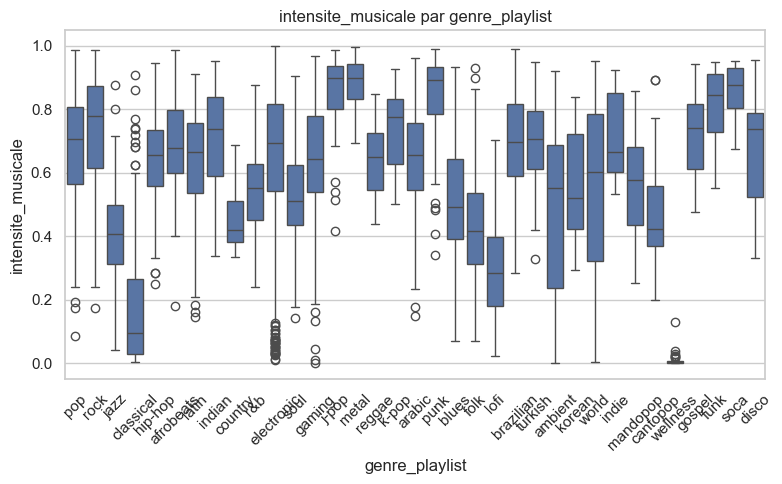


Analyse bivariée (num-cat) : dansabilite vs collaboration
dansabilite selon collaboration
                   mean       std     min    max
collaboration                                   
0              0.604666  0.191110  0.0589  0.979
1              0.655394  0.176511  0.0623  0.977

ANOVA F-stat : 81.35
P-value : 0.00000


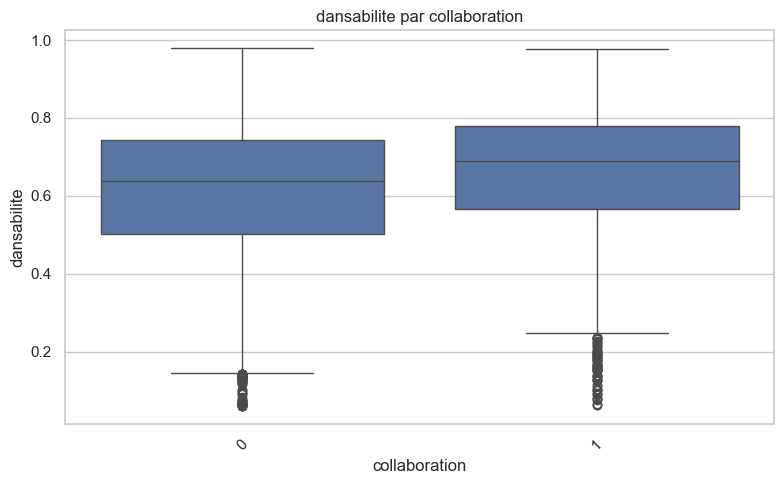

In [80]:

analyse_bivariee(df, "popularite_morceau", "genre_playlist", "num-cat")
analyse_bivariee(df, "intensite_musicale", "genre_playlist", "num-cat")
analyse_bivariee(df, "dansabilite", "collaboration", "num-cat")

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set(style="whitegrid")

def analyse_cat_vs_target(df, categorical_cols, target):

    for col in categorical_cols:

        print("\n" + "="*80)
        print(f"{col} vs {target}")
        print("="*80)

        # =========================
        # Table de contingence
        # =========================
        contingency = pd.crosstab(df[col], df[target])
        print("Table de contingence :")
        print(contingency)

        # =========================
        # Chi2 test
        # =========================
        chi2, p, dof, _ = chi2_contingency(contingency)

        print(f"\nChi2 : {chi2:.2f}")
        print(f"P-value : {p:.5f}")

        if p < 0.05:
            print("→ Dépendance SIGNIFICATIVE")
        else:
            print("→ Pas de dépendance significative")

        # =========================
        # Normalisation (%)
        # =========================
        contingency_pct = contingency.div(contingency.sum(axis=1), axis=0)

        # =========================
        # Plot propre
        # =========================
        plt.figure(figsize=(8,5))
        contingency_pct.plot(kind="bar", stacked=True)

        plt.title(f"{col} vs {target} (distribution %)")
        plt.ylabel("Proportion")
        plt.xticks(rotation=45)
        plt.legend(title=target)
        plt.tight_layout()
        plt.show()


genre_playlist vs classe_popularite
Table de contingence :
classe_popularite  bas  moyen  élevé  très élevé
genre_playlist                                  
afrobeats           32     24     26           0
ambient            196     93     61           9
arabic             109     46     45           8
blues               19     19     48           2
brazilian          101     32     15           0
cantopop            27      0      0           0
classical           72     37     12           0
country              6      2      3           0
disco                8      1      0           0
electronic         226    194    154          15
folk                21     11     30           6
funk                27      1      0           0
gaming              25      7     50          51
gospel              21     18      0           0
hip-hop             67     69    227          32
indian              30     14     13           0
indie                0     12      5           0
j-pop    

<Figure size 800x500 with 0 Axes>

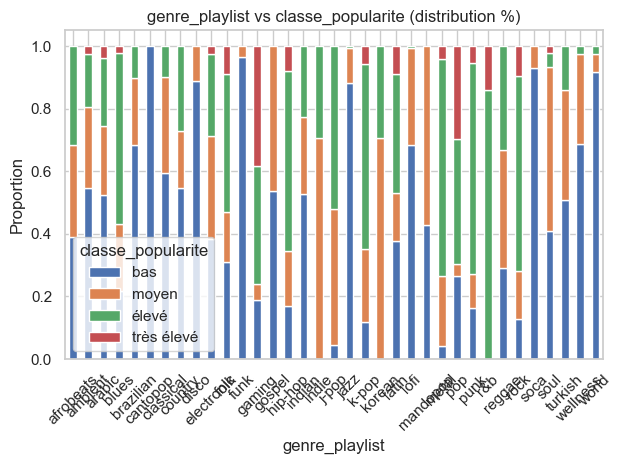


sous_genre_playlist vs classe_popularite
Table de contingence :
classe_popularite    bas  moyen  élevé  très élevé
sous_genre_playlist                               
80s                    0      1     38           6
90s                    0     13     29           1
academic               9      3     34           8
african               16     19     15           0
afro house             2     19     14           1
...                  ...    ...    ...         ...
trap                  18      4     34           4
tropical              12     42      6           2
vaporwave              0      9     13           0
workout                4      8      4           0
yoga                  55     23      2           0

[84 rows x 4 columns]

Chi2 : 4337.57
P-value : 0.00000
→ Dépendance SIGNIFICATIVE


<Figure size 800x500 with 0 Axes>

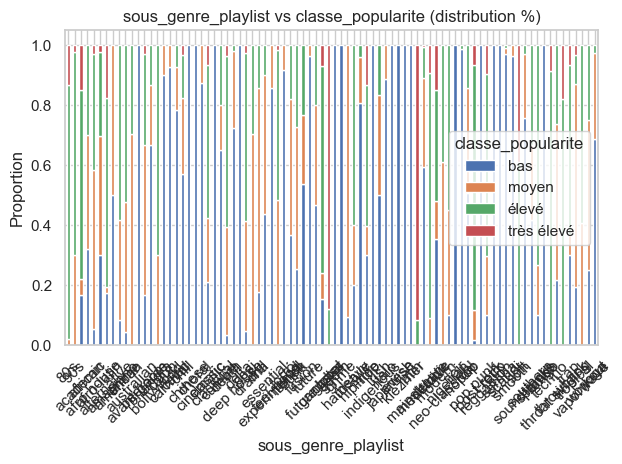


signature_rythmique vs classe_popularite
Table de contingence :
classe_popularite     bas  moyen  élevé  très élevé
signature_rythmique                                
1.0                    17     12      8           0
3.0                   171     72     64          39
4.0                  1755    862   1357         322
5.0                    78     41     31           1

Chi2 : 58.38
P-value : 0.00000
→ Dépendance SIGNIFICATIVE


<Figure size 800x500 with 0 Axes>

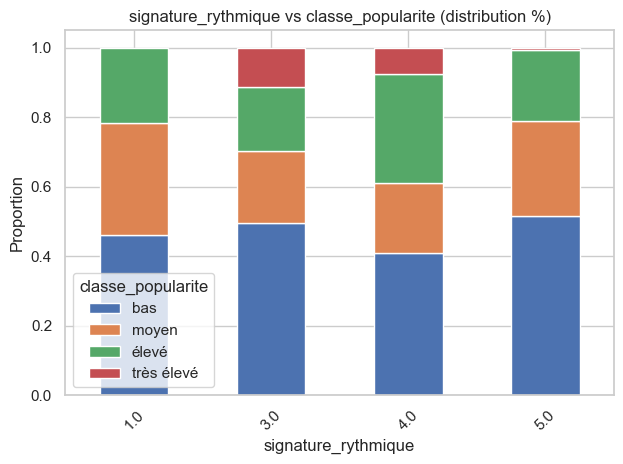


collaboration vs classe_popularite
Table de contingence :
classe_popularite   bas  moyen  élevé  très élevé
collaboration                                    
0                  1382    604    918         246
1                   639    383    542         116

Chi2 : 20.68
P-value : 0.00012
→ Dépendance SIGNIFICATIVE


<Figure size 800x500 with 0 Axes>

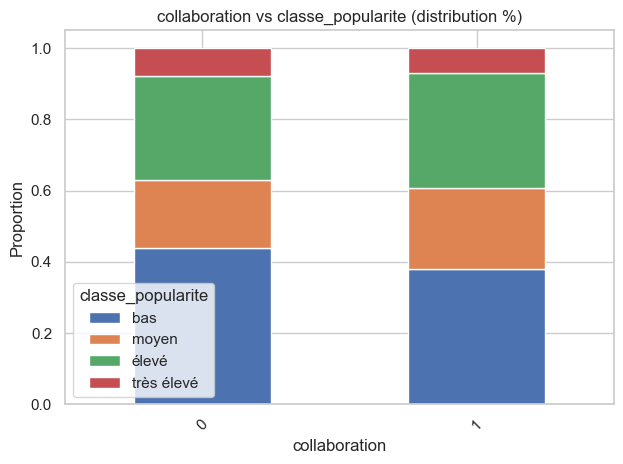

In [82]:
categorical_cols = [
    "genre_playlist",
    "sous_genre_playlist",
    "signature_rythmique",
    "collaboration"
]

analyse_cat_vs_target(df, categorical_cols, "classe_popularite")

<br>
<br><br>
<br>

## **9. Analyse multivariée des variables**

L’analyse multivariée consiste à étudier simultanément plusieurs variables afin de comprendre leurs interactions globales, détecter des structures cachées et identifier les facteurs les plus influents dans la prédiction de la popularité des morceaux.

<br>
<br>

##### **Objectifs de l’analyse**

- Comprendre les relations complexes entre plusieurs variables
- Identifier les variables les plus importantes pour la prédiction
- Détecter les interactions entre variables
- Réduire la dimensionnalité si nécessaire
- Améliorer la performance des modèles

<br>
<br>

##### **Méthodes utilisées**

<br>

###### **Matrice de corrélation**

Analyse des corrélations entre variables numériques :

- `intensite_musicale`
- `dansabilite`
- `tonalite_emotionnelle_positive`
- `niveau_sonore`
- `battement_par_minute`
- `duree_ms`
- `probabilite_is_acoustique`
- `presence_parole`

**Objectif :**

- Identifier les variables fortement corrélées
- Détecter la redondance d’information
- Comprendre les relations globales

<br>

###### **Analyse des interactions variables / target**

Étude de l’influence combinée des variables sur :

- `popularite_morceau`

**Approches :**

- Importance des variables (feature importance avec RandomForest)
- Analyse des distributions conditionnelles
- Comparaison des performances avec différents groupes de variables

<br>

###### **Réduction de dimension (optionnel)**

Techniques possibles :

- PCA (Principal Component Analysis)

**Objectif :**

- Réduire le nombre de variables
- Visualiser les données dans un espace simplifié
- Capturer l’information principale

<br>

###### **Analyse par groupes (segmentation)**

Regroupement des observations selon leurs caractéristiques :

- Clustering (KMeans, etc.)
- Analyse des profils de morceaux

**Objectif :**

- Identifier des types de morceaux (clusters)
- Comprendre les profils musicaux dominants

<br>
<br>

##### **Insights attendus**

- Identification des variables les plus influentes sur la popularité
- Détection de relations complexes non visibles en analyse bivariée
- Réduction de la complexité du modèle
- Meilleure compréhension globale du dataset

<br>
<br>

Appui visuel à la sélection des variables

Avant de lancer les modèles, il est utile de regarder quelques visualisations ciblées pour vérifier si les variables retenues portent effectivement un signal intéressant. L'objectif n'est pas de prouver mathématiquement qu'une variable est bonne, mais de montrer qu'il existe une structure visible dans les données qui rend nos choix plausibles et cohérents.

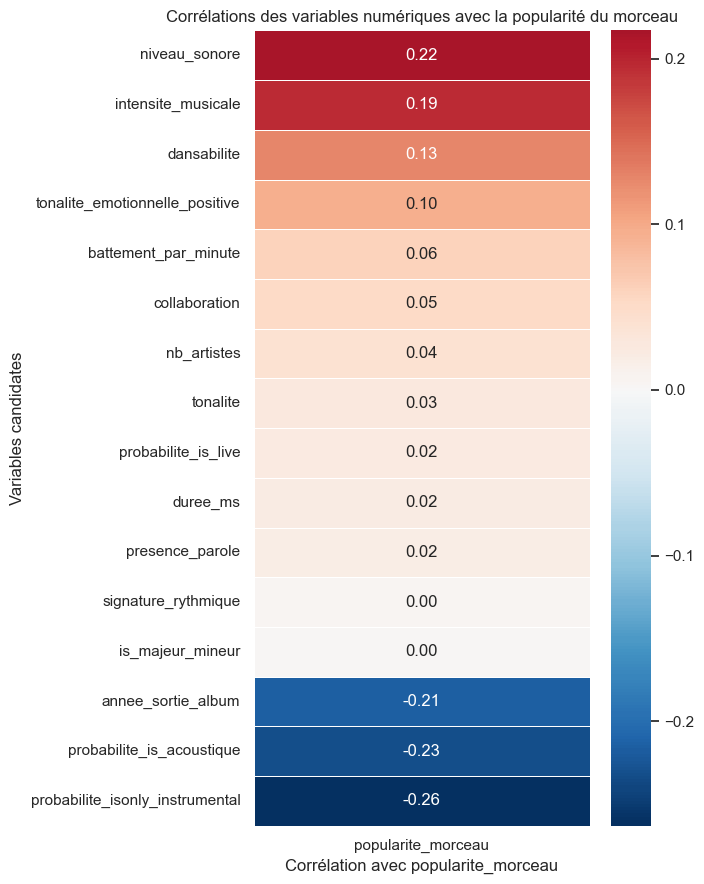

In [83]:
def parse_mixed_date(x):
    if pd.isna(x):
        return pd.NaT
    x = str(x)
    try:
        if "/" in x:
            return pd.to_datetime(x, format="%d/%m/%Y", errors="coerce")
        elif len(x) == 4:
            return pd.to_datetime(x, format="%Y", errors="coerce")
        elif len(x) == 7:
            return pd.to_datetime(x, format="%Y-%m", errors="coerce")
        else:
            return pd.to_datetime(x, format="%Y-%m-%d", errors="coerce")
    except:
        return pd.NaT

df["annee_sortie_album"] = df["date_sortie_album"].apply(parse_mixed_date).dt.year


numeric_support_cols = [
    'popularite_morceau',
    'battement_par_minute',
    'niveau_sonore',
    'duree_ms',
    'tonalite',
    'is_majeur_mineur',
    'signature_rythmique',
    'intensite_musicale',
    'dansabilite',
    'tonalite_emotionnelle_positive',
    'presence_parole',
    'probabilite_is_acoustique',
    'probabilite_isonly_instrumental',
    'probabilite_is_live',
    'nb_artistes',
    'collaboration',
    'annee_sortie_album'
]

corr_with_popularity = (
    df[numeric_support_cols]
    .corr(numeric_only=True)[['popularite_morceau']]
    .drop(index='popularite_morceau')
    .sort_values('popularite_morceau', ascending=False)
)

plt.figure(figsize=(7, 9))
sns.heatmap(
    corr_with_popularity,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)
plt.title("Corrélations des variables numériques avec la popularité du morceau")
plt.xlabel("Corrélation avec popularite_morceau")
plt.ylabel("Variables candidates")
plt.tight_layout()
plt.show()

Cette heatmap sert surtout à soutenir les modèles AUDIO et PLATEFORME. Si une variable est un peu corrélée à la popularité, cela ne garantit pas qu'elle sera décisive seule, mais cela justifie qu'on la teste dans un modèle. À l'inverse, si une variable n'a quasiment aucun signal visible, on sait qu'il faudra rester prudent sur son utilité.

On regarde la répartition des classes de popularité selon le genre et le sous-genre de playlist parce que je veux vérifier si les variables catégorielles du modèle PLATEFORME apportent une information structurée, et techniquement une heatmap normalisée par ligne permet de voir si certaines familles musicales sont plus souvent associées à certaines classes de popularité.

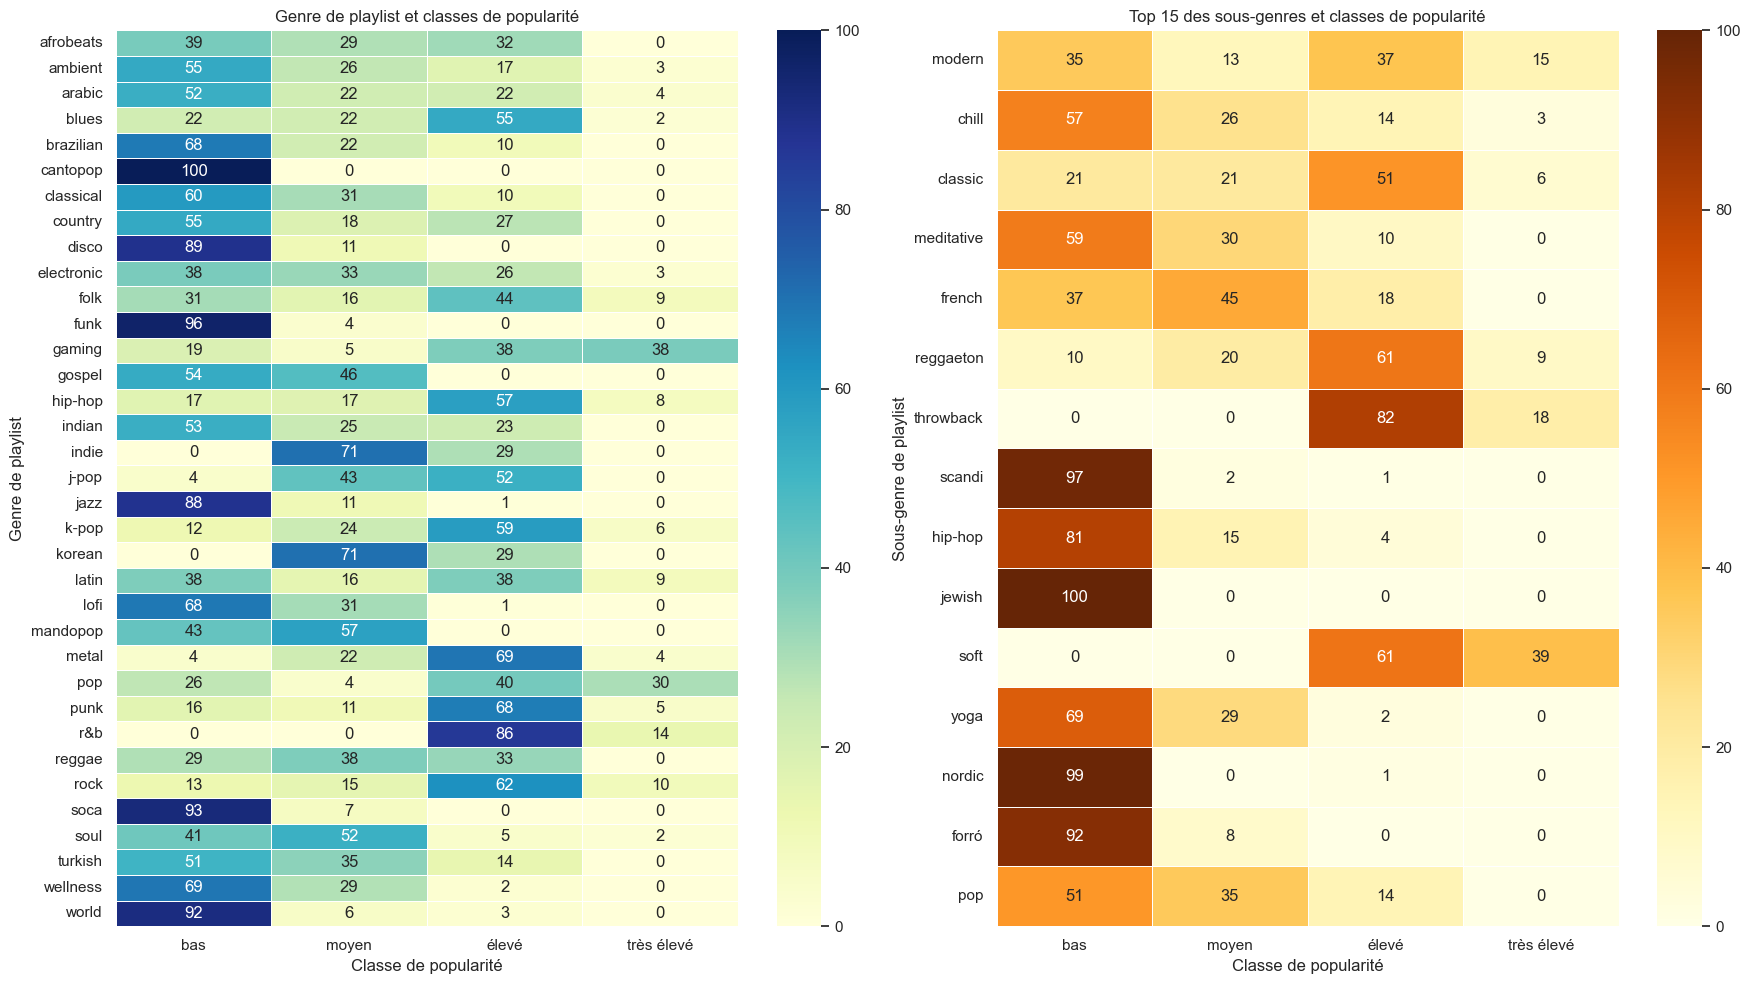

In [84]:

genre_heatmap = pd.crosstab(
    df['genre_playlist'],
    df['classe_popularite'],
    normalize='index'
).reindex(columns=labels) * 100

top_subgenres = df['sous_genre_playlist'].value_counts().head(15).index
subgenre_heatmap = pd.crosstab(
    df.loc[df['sous_genre_playlist'].isin(top_subgenres), 'sous_genre_playlist'],
    df.loc[df['sous_genre_playlist'].isin(top_subgenres), 'classe_popularite'],
    normalize='index'
).reindex(columns=labels) * 100
subgenre_heatmap = subgenre_heatmap.loc[top_subgenres]

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

sns.heatmap(genre_heatmap, cmap='YlGnBu', annot=True, fmt='.0f', ax=axes[0], linewidths=0.5)
axes[0].set_title("Genre de playlist et classes de popularité")
axes[0].set_xlabel("Classe de popularité")
axes[0].set_ylabel("Genre de playlist")

sns.heatmap(subgenre_heatmap, cmap='YlOrBr', annot=True, fmt='.0f', ax=axes[1], linewidths=0.5)
axes[1].set_title("Top 15 des sous-genres et classes de popularité")
axes[1].set_xlabel("Classe de popularité")
axes[1].set_ylabel("Sous-genre de playlist")

plt.tight_layout()
plt.show()


Ces heatmaps soutiennent directement le choix de `genre_playlist` et `sous_genre_playlist` dans le modèle PLATEFORME. Si les pourcentages étaient très semblables partout, ces variables seraient peu convaincantes. Si certaines lignes se concentrent davantage sur des classes particulières, cela signifie que le contexte de playlist porte probablement une information utile pour la prédiction.
<br>
<br>
<br>
<br>

Puis, on regarde des patterns liés aux artistes parce que je veux justifier les variables du modèle ARTISTE malgré la forte cardinalité des noms d'artistes, et techniquement je combine une heatmap sur les artistes principaux les plus fréquents avec une heatmap sur la collaboration pour voir si les distributions changent selon la classe de popularité.

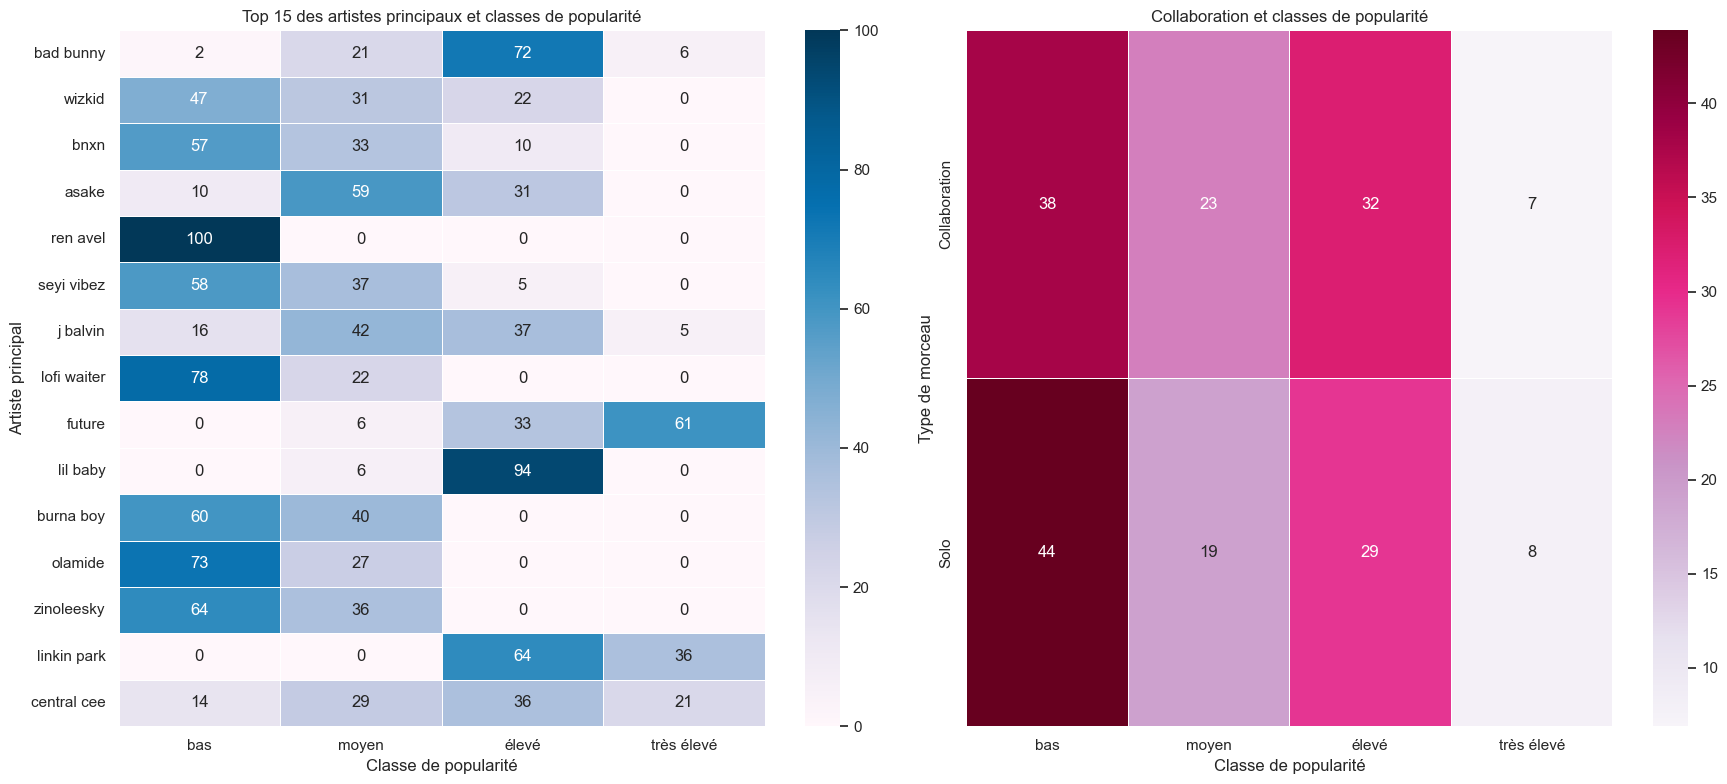

In [85]:

top_artistes = df['artiste_principal'].value_counts().head(15).index
artist_heatmap = pd.crosstab(
    df.loc[df['artiste_principal'].isin(top_artistes), 'artiste_principal'],
    df.loc[df['artiste_principal'].isin(top_artistes), 'classe_popularite'],
    normalize='index'
).reindex(columns=labels) * 100
artist_heatmap = artist_heatmap.loc[top_artistes]

collab_labels = df['collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_heatmap = pd.crosstab(
    collab_labels,
    df['classe_popularite'],
    normalize='index'
).reindex(columns=labels) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(artist_heatmap, cmap='PuBu', annot=True, fmt='.0f', ax=axes[0], linewidths=0.5)
axes[0].set_title("Top 15 des artistes principaux et classes de popularité")
axes[0].set_xlabel("Classe de popularité")
axes[0].set_ylabel("Artiste principal")

sns.heatmap(collab_heatmap, cmap='PuRd', annot=True, fmt='.0f', ax=axes[1], linewidths=0.5)
axes[1].set_title("Collaboration et classes de popularité")
axes[1].set_xlabel("Classe de popularité")
axes[1].set_ylabel("Type de morceau")

plt.tight_layout()
plt.show()


Cette dernière visualisation soutient le modèle ARTISTE. Elle permet de voir si l'identité de certains artistes fréquents et le fait d'être en collaboration semblent associés à des répartitions différentes de popularité. Cela ne prouve pas qu'un artiste cause la popularité, mais cela justifie de traiter ces informations comme des variables potentiellement utiles plutôt que comme du simple bruit.

<br>
<br>
<br>
<br>

#### **Intégration de `popularite_artistes_max**

On ajoute la variable `popularite_artistes_max`. L'idée est de tester si cette information issue des artistes apporte un signal complémentaire au bloc plateforme, puis de mesurer très concrètement son effet sur les métriques du jeu de test.

On prépare les jeux d'entraînement et de test enrichis parce que `popularite_artistes_max` a été calculée dans `df_fr_enrichi` et n'est donc pas encore présente dans `X_train` et `X_test`. Techniquement, je reconstruis simplement deux vues alignées sur les mêmes index pour pouvoir réutiliser exactement le même découpage train/test que dans le reste du notebook.

In [86]:
def ajouter_colonnes_popularite_artistes(df):

    df["popularite_morceau"] = pd.to_numeric(df["popularite_morceau"], errors="coerce")

    temp = df.assign(
        artiste=df["nom_artiste"].astype(str).str.split(",")
    ).explode("artiste")

    temp["artiste"] = temp["artiste"].str.strip()
    temp = temp[(temp["artiste"].notna()) & (temp["artiste"] != "")]

    moyenne_par_artiste = temp.groupby("artiste")["popularite_morceau"].mean()

    def compute_stats(artistes):
        if pd.isna(artistes):
            return [], np.nan, np.nan

        artistes_liste = [a.strip() for a in str(artistes).split(",") if a.strip()]
        valeurs = moyenne_par_artiste.reindex(artistes_liste).dropna().tolist()

        if len(valeurs) == 0:
            return [], np.nan, np.nan

        return (
            [round(float(v), 2) for v in valeurs],
            round(float(np.mean(valeurs)), 2),
            round(float(np.max(valeurs)), 2)
        )

    stats = df["nom_artiste"].apply(compute_stats)

    df["popularite_artiste_liste"] = stats.apply(lambda x: x[0])
    df["popularite_artiste_moyenne"] = stats.apply(lambda x: x[1])
    df["popularite_artiste_max"] = stats.apply(lambda x: x[2])

    return moyenne_par_artiste.reset_index(name="popularite_moyenne_artiste")

popularite_par_artiste = ajouter_colonnes_popularite_artistes(df)

<br>
<br>
On définit une nouvelle version du modèle régularisé en ajoutant `popularite_artistes_max` à la liste des variables numériques.

In [87]:
df.head()


,intensite_musicale,battement_par_minute,dansabilite,genre_playlist,niveau_sonore,probabilite_is_live,tonalite_emotionnelle_positive,nom_artiste,signature_rythmique,presence_parole,...,id_playlist,fichier_origine,nb_artistes,collaboration,artiste_principal,classe_popularite,annee_sortie_album,popularite_artiste_liste,popularite_artiste_moyenne,popularite_artiste_max
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,37i9dQZF1DXcBWIGoYBM5M,high,2,1,lady gaga,très élevé,2024,"[88.14, 89.36]",88.75,89.36
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,37i9dQZF1DXcBWIGoYBM5M,high,1,0,billie eilish,très élevé,2024,[84.15],84.15,84.15
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,37i9dQZF1DXcBWIGoYBM5M,high,1,0,gracie abrams,très élevé,2024,[87.8],87.80,87.80
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,37i9dQZF1DXcBWIGoYBM5M,high,1,0,sabrina carpenter,très élevé,2024,[88.0],88.00,88.00
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,37i9dQZF1DXcBWIGoYBM5M,high,2,1,rosé,très élevé,2024,"[98.0, 89.36]",93.68,98.00


<br>
<br><br>
<br>

## **10. Séparation train / test avec stratification**



Nous séparons les données en un jeu d'entraînement et un jeu de test afin d'évaluer les modèles sur des données qu'ils n'ont jamais vues, tout en conservant la même structure de classes dans les deux jeux.

On sépare les données entre entraînement et test parce que je veux mesurer la capacité de généralisation sur des observations non vues, et techniquement `train_test_split` avec `stratify=y` conserve une répartition comparable des classes dans les deux sous-ensembles.

<br>
<br>

In [88]:
X = df.drop(columns=["classe_popularite"])
y = df["classe_popularite"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())

(3864, 36) (966, 36)
classe_popularite
bas           0.418478
moyen         0.204451
élevé         0.302277
très élevé    0.074793
Name: proportion, dtype: float64
classe_popularite
bas           0.418219
moyen         0.203934
élevé         0.302277
très élevé    0.075569
Name: proportion, dtype: float64


<br>
<br>
<br>
<br>

## **11. Construction des pipelines**
<br>
<br>

Nous construisons ici trois pipelines distincts pour automatiser le prétraitement et l'entraînement de chaque modèle, ce qui rend la démarche plus robuste, plus lisible et plus facile à comparer.

On construit les trois pipelines parce que je veux lier proprement le prétraitement et le modèle final dans un seul objet, et techniquement `ColumnTransformer` applique le bon traitement à chaque type de variable tandis que `Pipeline` enchaîne ce traitement avec l'estimateur choisi.


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import pandas as pd
import time

# =========================
# Groupes de variables
# =========================

num_spotify = [
    "intensite_musicale",
    "dansabilite",
    "tonalite_emotionnelle_positive",
    "probabilite_is_acoustique",
    "probabilite_isonly_instrumental",
    "probabilite_is_live",
    "niveau_sonore"
]

num_general = [
    "tonalite",
    "duree_ms",
    "battement_par_minute",
    "presence_parole"
]

num_artiste = [
    "nb_artistes",
    "annee_sortie_album"
]

num_artiste_plus = [
    "popularite_artiste_max"
]

cat_spotify = [
    "genre_playlist",
    "sous_genre_playlist"
]

cat_general = [
    "signature_rythmique"
]

cat_artiste = [
    "collaboration",
]

cat_artiste_nom = [
    "artiste_principal"
]

target = "classe_popularite"

# =========================
# SPLIT GLOBAL
# =========================

all_features = num_spotify + num_general + num_artiste + num_artiste_plus + cat_spotify + cat_general + cat_artiste + cat_artiste_nom
all_features = [col for col in all_features if col in df.columns]

X = df[all_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# FONCTION MODELE
# =========================

def build_pipeline_model(
    X_train, X_test, y_train, y_test,
    num_cols,
    cat_cols,
    model_name="Model",
    num_imputer_strategy="median",
    cat_imputer_strategy="most_frequent",
    scaler=StandardScaler(),
    encoder=OneHotEncoder(handle_unknown="ignore"),
    model_class=RandomForestClassifier,
    model_params=None,
    **model_kwargs
):

    import time
    from sklearn.metrics import f1_score
    from sklearn.model_selection import cross_val_score

    # =========================
    # MERGE PARAMS (clé du fix)
    # =========================
    final_model_params = {}

    if model_params is not None:
        final_model_params.update(model_params)

    final_model_params.update(model_kwargs)

    # DEFAULTS si rien fourni
    if len(final_model_params) == 0:
        final_model_params = {
            "n_estimators": 200,
            "random_state": 42,
            "class_weight": "balanced",
            "n_jobs": -1
        }

    # =========================
    # PIPELINES
    # =========================
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy=num_imputer_strategy)),
        ("scaler", scaler)
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy=cat_imputer_strategy)),
        ("encoder", encoder)
    ])

    transformers = []

    if num_cols:
        transformers.append(("num", numeric_pipeline, num_cols))

    if cat_cols:
        transformers.append(("cat", categorical_pipeline, cat_cols))

    preprocessor = ColumnTransformer(transformers)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model_class(**final_model_params))
    ])

    # =========================
    # TRAIN
    # =========================
    start = time.time()
    pipeline.fit(X_train[num_cols + cat_cols], y_train)
    train_time = time.time() - start

    y_pred_train = pipeline.predict(X_train[num_cols + cat_cols])
    y_pred_test = pipeline.predict(X_test[num_cols + cat_cols])

    # =========================
    # METRICS
    # =========================
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    train_f1 = f1_score(y_train, y_pred_train, average="macro")
    test_f1 = f1_score(y_test, y_pred_test, average="macro")

    cv_scores_acc = cross_val_score(
        pipeline,
        X_train[num_cols + cat_cols],
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_scores_f1 = cross_val_score(
        pipeline,
        X_train[num_cols + cat_cols],
        y_train,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_acc = cv_scores_acc.mean()
    cv_f1 = cv_scores_f1.mean()

    # =========================
    # OUTPUT
    # =========================
    print("\n" + "="*100)
    print(model_name)
    print("="*100)

    print("Model params:", final_model_params)

    print("\nPerformance")
    print(classification_report(y_test, y_pred_test))
    print("Accuracy :", round(test_acc, 4))

    return {
        "name": model_name,
        "pipeline": pipeline,
        "features": num_cols + cat_cols,
        "train_accuracy": train_acc,
        "cv_accuracy": cv_acc,
        "test_accuracy": test_acc,
        "train_f1_macro": train_f1,
        "cv_f1_macro": cv_f1,
        "test_f1_macro": test_f1,
        "train_time_sec": train_time
    }

# =========================
# MODELES
# =========================

results = []

# =========================
# LOGISTIC REGRESSION (AUDIO SPOTIFY)
# =========================
results.append(build_pipeline_model(
    X_train, X_test, y_train, y_test,
    num_cols=num_spotify,
    cat_cols=[],
    model_name="SPOTIFY AUDIO / Sans artiste (LogisticRegression)",
    model_class=LogisticRegression,
    max_iter=3000,
    class_weight="balanced"
))


# =========================
# LOGISTIC REGRESSION (GLOBAL AUDIO)
# =========================
results.append(build_pipeline_model(
    X_train, X_test, y_train, y_test,
    num_cols=num_spotify + num_general,
    cat_cols=[],
    model_name="GLOBAL AUDIO / Sans artiste (LogisticRegression)",
    model_class=LogisticRegression,
    max_iter=3000,
    class_weight="balanced"
))


# =========================
# LOGISTIC REGRESSION (ARTISTE)
# =========================
results.append(build_pipeline_model(
    X_train, X_test, y_train, y_test,
    num_cols=num_artiste,
    cat_cols=cat_artiste + cat_artiste_nom,
    model_name="ARTISTE (LogisticRegression)",
    encoder=OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10),
    model_class=LogisticRegression,
    max_iter=3000,
    class_weight="balanced",
    solver="saga",
    penalty="l2"
))


# =========================
# PARAMS RANDOM FOREST (COMMUNS)
# =========================
rf_params = dict(
    n_estimators=250,
    max_depth=10,
    max_features='sqrt',
    min_samples_split=25,
    min_samples_leaf=8,
    max_samples=0.7,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)


# =========================
# FULL AVEC ARTISTE
# =========================
results.append(build_pipeline_model(
    X_train, X_test, y_train, y_test,
    num_cols=num_spotify + num_general + num_artiste,
    cat_cols=cat_spotify + cat_general + cat_artiste,
    model_name="GLOBAL / Avec artiste (RandomForest)",
    model_class=RandomForestClassifier,
    **rf_params
))


# =========================
# FULL AVEC ARTISTE AMELIORE
# =========================
results.append(build_pipeline_model(
    X_train, X_test, y_train, y_test,
    num_cols=num_spotify + num_general + num_artiste + num_artiste_plus,
    cat_cols=cat_spotify + cat_general + cat_artiste,
    model_name="GLOBAL / Avec artiste amelioré (RandomForest)",
    model_class=RandomForestClassifier,
    **rf_params
))


# =========================
# STRUCTURES FINALES
# =========================

models = {model["name"]: model for model in results}

pipelines = {
    name: (model["pipeline"], model["features"])
    for name, model in models.items()
}


SPOTIFY AUDIO / Sans artiste (LogisticRegression)
Model params: {'max_iter': 3000, 'class_weight': 'balanced'}

Performance
              precision    recall  f1-score   support

         bas       0.69      0.42      0.52       404
       moyen       0.22      0.16      0.18       197
  très élevé       0.12      0.51      0.19        73
       élevé       0.37      0.33      0.35       292

    accuracy                           0.34       966
   macro avg       0.35      0.35      0.31       966
weighted avg       0.45      0.34      0.37       966

Accuracy : 0.3437

GLOBAL AUDIO / Sans artiste (LogisticRegression)
Model params: {'max_iter': 3000, 'class_weight': 'balanced'}

Performance
              precision    recall  f1-score   support

         bas       0.68      0.41      0.51       404
       moyen       0.22      0.16      0.19       197
  très élevé       0.14      0.58      0.22        73
       élevé       0.40      0.37      0.38       292

    accuracy              

In [90]:
df["artiste_principal"]


0                lady gaga
1            billie eilish
2            gracie abrams
3        sabrina carpenter
4                     rosé
               ...        
4826    m. s. subbulakshmi
4827     jayanthi kumaresh
4828     nirmala rajasekar
4829                ganesh
4830      sudha ragunathan
Name: artiste_principal, Length: 4830, dtype: object

<br>
<br>
<br>
<br>

## **12. Validation croisée et fonctions d'évaluation**
<br>
<br>

Cette section définit le cadre d'évaluation commun à tous les modèles afin que la comparaison soit juste, reproductible et fondée sur les mêmes métriques.

Dans cette cellule, je mets en place la validation croisée et les fonctions d'évaluation parce que je veux comparer les modèles avec exactement le même protocole, et techniquement `StratifiedKFold`, `cross_validate` et les métriques de classification permettent d'obtenir des scores plus stables qu'un simple split unique.

<br>
<br>


In [91]:
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt
import time


# =========================
# CONFIG CV & SCORING
# =========================
def get_cv(n_splits=5, shuffle=True, random_state=42):
    return StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)


def get_scoring():
    return {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    }


# =========================
# METRICS
# =========================
def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }


# =========================
# CONFUSION MATRIX ANALYSIS
# =========================
def analyze_confusion_matrix(cm, classes):
    row_totals = cm.sum(axis=1)

    recalls = np.divide(
        np.diag(cm),
        row_totals,
        out=np.zeros_like(np.diag(cm), dtype=float),
        where=row_totals != 0
    )

    best_idx = int(np.argmax(recalls))
    worst_idx = int(np.argmin(recalls))

    cm_offdiag = cm.copy()
    np.fill_diagonal(cm_offdiag, 0)
    max_conf = cm_offdiag.max()

    print(f"Best class: '{classes[best_idx]}' (recall={recalls[best_idx]:.3f})")
    print(f"Worst class: '{classes[worst_idx]}' (recall={recalls[worst_idx]:.3f})")

    if max_conf > 0:
        i, j = np.argwhere(cm_offdiag == max_conf)[0]
        print(f"Most confusion: true='{classes[i]}' predicted='{classes[j]}' → {int(max_conf)} cases")


# =========================
# EVALUATION PIPELINE (CORRIGÉ)
# =========================
def evaluate_pipeline(
    name,
    pipeline,
    features,
    X_train,
    X_test,
    y_train,
    y_test,
    cv=None,
    scoring=None,
    plot_cm=True
):

    if cv is None:
        cv = get_cv()

    if scoring is None:
        scoring = get_scoring()

    print("\n" + "="*100)
    print(f"MODEL: {name}")
    print("="*100)

    X_train_sub = X_train[features]
    X_test_sub = X_test[features]

    # CV
    cv_results = cross_validate(
        pipeline,
        X_train_sub,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    # Fit final model
    model = clone(pipeline)
    start = time.perf_counter()
    model.fit(X_train_sub, y_train)
    train_time = time.perf_counter() - start

    # Predictions
    y_pred_train = model.predict(X_train_sub)
    y_pred_test = model.predict(X_test_sub)

    # Metrics
    train_metrics = compute_metrics(y_train, y_pred_train)
    test_metrics = compute_metrics(y_test, y_pred_test)

    for metric in scoring.keys():
        print(
            f"{metric} | train={train_metrics[metric]:.4f} | "
            f"cv={cv_results['test_' + metric].mean():.4f} | "
            f"test={test_metrics[metric]:.4f}"
        )

    print(f"Training time: {train_time:.3f}s")

    # ORDRE MÉTIER FIXE
    classes_order = ["bas", "moyen", "élevé", "très élevé"]
    classes = [c for c in classes_order if c in np.unique(y_test)]

    print("\nClassification report:")
    print(classification_report(y_test, y_pred_test, labels=classes, target_names=classes, zero_division=0))

    cm = confusion_matrix(y_test, y_pred_test, labels=classes)

    print("\nConfusion matrix:")
    print(cm)

    analyze_confusion_matrix(cm, classes)

    if plot_cm:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        fig, ax = plt.subplots(figsize=(7, 6))
        disp.plot(ax=ax, cmap='Blues', xticks_rotation=30, colorbar=False)
        ax.set_title(f"Confusion Matrix - {name}")
        plt.show()

    return {
        "name": name,
        "model": model,
        "cv_results": cv_results,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "train_time": train_time
    }


# =========================
# LEARNING CURVE (CORRIGÉ)
# =========================
def plot_learning_curve(
    model,
    X,
    y,
    features,
    title="Learning Curve",
    cv=None,
    scoring="f1_macro"
):

    if cv is None:
        cv = get_cv()

    X_sub = X[features]

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_sub,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker='o', label="Train")
    plt.plot(train_sizes, val_mean, marker='o', label="Validation")

    plt.title(title)
    plt.xlabel("Training size")
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(True)
    plt.show()

Nous lançons maintenant l'entraînement et l'évaluation des trois pipelines pour observer leurs performances respectives sur l'entraînement, la validation croisée et le test final.

On lance l'évaluation des trois modèles de base parce que on veut voir lequel apprend vraiment quelque chose et lequel surapprend, et techniquement la boucle appelle la même fonction d'évaluation pour chaque pipeline afin de rendre la comparaison directe et équitable.



MODEL: SPOTIFY AUDIO / Sans artiste (LogisticRegression)
accuracy | train=0.3468 | cv=0.3408 | test=0.3437
precision_macro | train=0.3523 | cv=0.3457 | test=0.3485
recall_macro | train=0.3688 | cv=0.3597 | test=0.3522
f1_macro | train=0.3160 | cv=0.3093 | test=0.3095
Training time: 0.051s

Classification report:
              precision    recall  f1-score   support

         bas       0.69      0.42      0.52       404
       moyen       0.22      0.16      0.18       197
       élevé       0.37      0.33      0.35       292
  très élevé       0.12      0.51      0.19        73

    accuracy                           0.34       966
   macro avg       0.35      0.35      0.31       966
weighted avg       0.45      0.34      0.37       966


Confusion matrix:
[[168  65  96  75]
 [ 49  31  44  73]
 [ 24  36  96 136]
 [  2  12  22  37]]
Best class: 'très élevé' (recall=0.507)
Worst class: 'moyen' (recall=0.157)
Most confusion: true='élevé' predicted='très élevé' → 136 cases


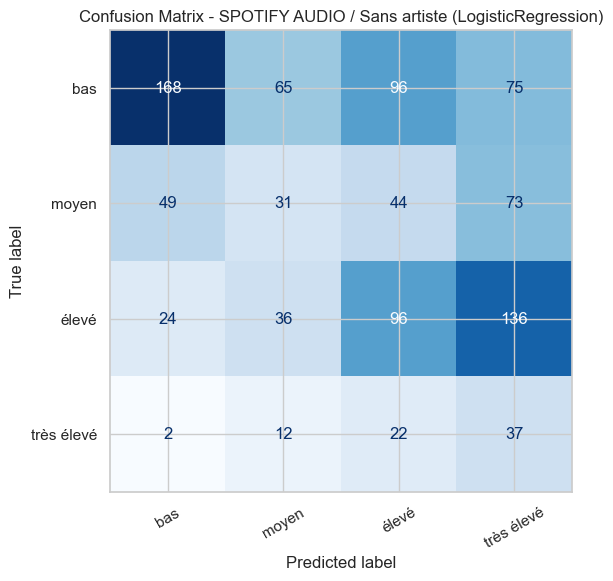


MODEL: GLOBAL AUDIO / Sans artiste (LogisticRegression)
accuracy | train=0.3579 | cv=0.3476 | test=0.3592
precision_macro | train=0.3653 | cv=0.3547 | test=0.3591
recall_macro | train=0.3919 | cv=0.3733 | test=0.3788
f1_macro | train=0.3284 | cv=0.3167 | test=0.3253
Training time: 0.046s

Classification report:
              precision    recall  f1-score   support

         bas       0.68      0.41      0.51       404
       moyen       0.22      0.16      0.19       197
       élevé       0.40      0.37      0.38       292
  très élevé       0.14      0.58      0.22        73

    accuracy                           0.36       966
   macro avg       0.36      0.38      0.33       966
weighted avg       0.46      0.36      0.38       966


Confusion matrix:
[[166  67  86  85]
 [ 50  32  57  58]
 [ 26  35 107 124]
 [  2  10  19  42]]
Best class: 'très élevé' (recall=0.575)
Worst class: 'moyen' (recall=0.162)
Most confusion: true='élevé' predicted='très élevé' → 124 cases


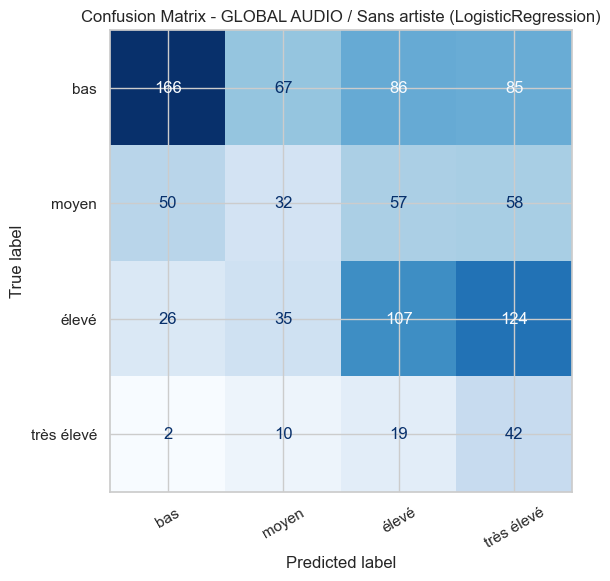


MODEL: ARTISTE (LogisticRegression)
accuracy | train=0.4493 | cv=0.4363 | test=0.4410
precision_macro | train=0.4023 | cv=0.3725 | test=0.3854
recall_macro | train=0.3817 | cv=0.3605 | test=0.3744
f1_macro | train=0.3868 | cv=0.3609 | test=0.3780
Training time: 0.503s

Classification report:
              precision    recall  f1-score   support

         bas       0.52      0.51      0.51       404
       moyen       0.24      0.31      0.27       197
       élevé       0.57      0.50      0.53       292
  très élevé       0.21      0.18      0.19        73

    accuracy                           0.44       966
   macro avg       0.39      0.37      0.38       966
weighted avg       0.46      0.44      0.45       966


Confusion matrix:
[[206 120  52  26]
 [ 98  61  32   6]
 [ 71  57 146  18]
 [ 24  12  24  13]]
Best class: 'bas' (recall=0.510)
Worst class: 'très élevé' (recall=0.178)
Most confusion: true='bas' predicted='moyen' → 120 cases


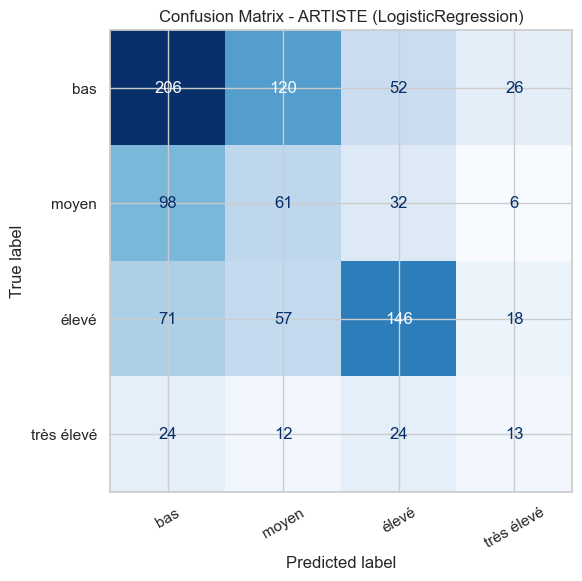


MODEL: GLOBAL / Avec artiste (RandomForest)
accuracy | train=0.6579 | cv=0.6015 | test=0.5973
precision_macro | train=0.6239 | cv=0.5598 | test=0.5563
recall_macro | train=0.6484 | cv=0.5754 | test=0.5707
f1_macro | train=0.6325 | cv=0.5639 | test=0.5613
Training time: 1.401s

Classification report:
              precision    recall  f1-score   support

         bas       0.76      0.66      0.71       404
       moyen       0.39      0.42      0.40       197
       élevé       0.58      0.64      0.61       292
  très élevé       0.49      0.56      0.52        73

    accuracy                           0.60       966
   macro avg       0.56      0.57      0.56       966
weighted avg       0.61      0.60      0.60       966


Confusion matrix:
[[265  87  49   3]
 [ 53  83  56   5]
 [ 27  42 188  35]
 [  2   1  29  41]]
Best class: 'bas' (recall=0.656)
Worst class: 'moyen' (recall=0.421)
Most confusion: true='bas' predicted='moyen' → 87 cases


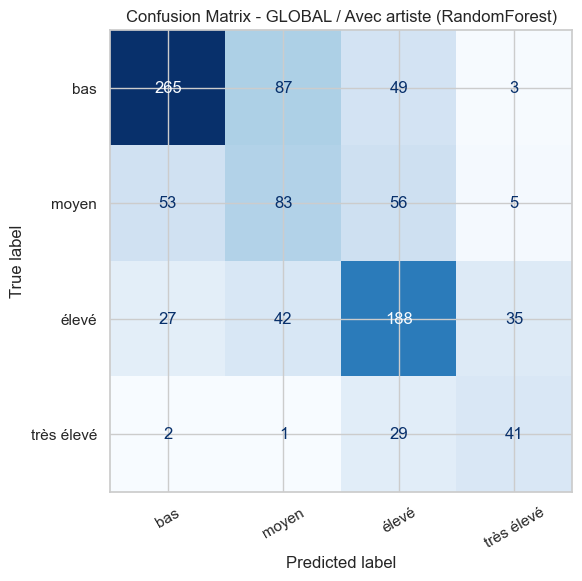


MODEL: GLOBAL / Avec artiste amelioré (RandomForest)
accuracy | train=0.8553 | cv=0.8269 | test=0.8168
precision_macro | train=0.8075 | cv=0.7675 | test=0.7717
recall_macro | train=0.8425 | cv=0.7937 | test=0.7939
f1_macro | train=0.8218 | cv=0.7775 | test=0.7796
Training time: 1.287s

Classification report:
              precision    recall  f1-score   support

         bas       0.96      0.86      0.91       404
       moyen       0.64      0.79      0.71       197
       élevé       0.83      0.80      0.81       292
  très élevé       0.65      0.73      0.69        73

    accuracy                           0.82       966
   macro avg       0.77      0.79      0.78       966
weighted avg       0.83      0.82      0.82       966


Confusion matrix:
[[346  56   2   0]
 [ 11 156  30   0]
 [  2  28 234  28]
 [  0   3  17  53]]
Best class: 'bas' (recall=0.856)
Worst class: 'très élevé' (recall=0.726)
Most confusion: true='bas' predicted='moyen' → 56 cases


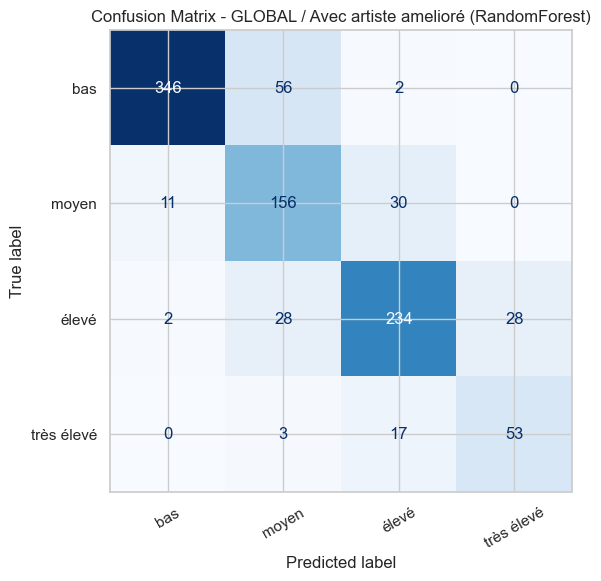

In [92]:
eval_results = []

for model in results:
    res = evaluate_pipeline(
        name=model["name"],
        pipeline=model["pipeline"],
        features=model["features"],
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )
    eval_results.append(res)

COMMENTAIRES


<br>
<br>
<br>
<br>

## **12. Learning curves**

<br>
<br>
Les courbes d’apprentissage permettent d’analyser le comportement des modèles en fonction de la quantité de données disponibles. Elles offrent une vision claire de la progression des performances entre l’entraînement et la validation, ce qui est essentiel pour diagnostiquer des problèmes comme le surapprentissage (overfitting) ou le sous-apprentissage (underfitting).

Dans cette section, les learning curves sont utilisées pour observer comment les scores évoluent lorsque la taille de l’échantillon d’entraînement augmente. L’objectif est d’identifier si le modèle bénéficie réellement de plus de données ou s’il atteint rapidement ses limites.

D’un point de vue technique, la fonction `learning_curve` calcule les performances du modèle sur plusieurs tailles d’entraînement, en évaluant à chaque fois les scores sur les données d’apprentissage et de validation. Cela permet de comparer directement les deux courbes et de comprendre si le modèle généralise correctement ou s’il reste dépendant des données d’entraînement.

<br>
<br>

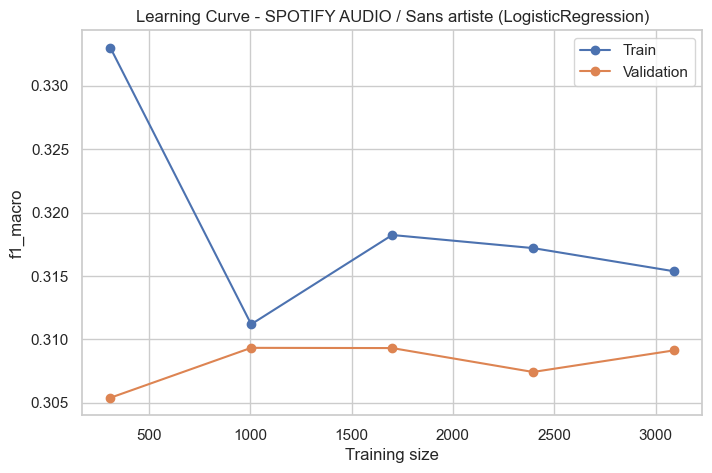

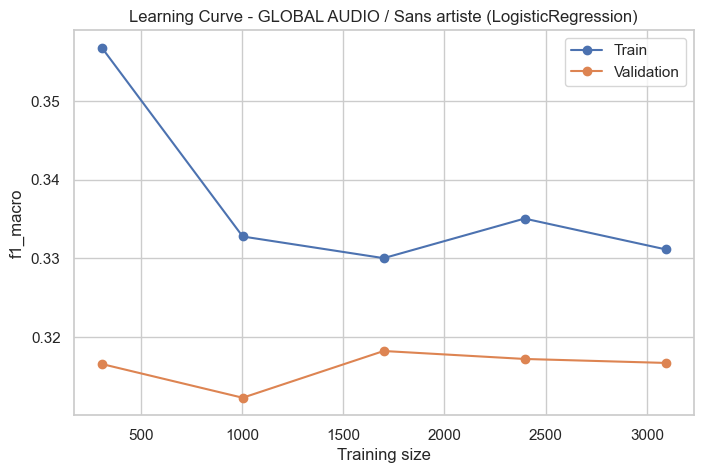

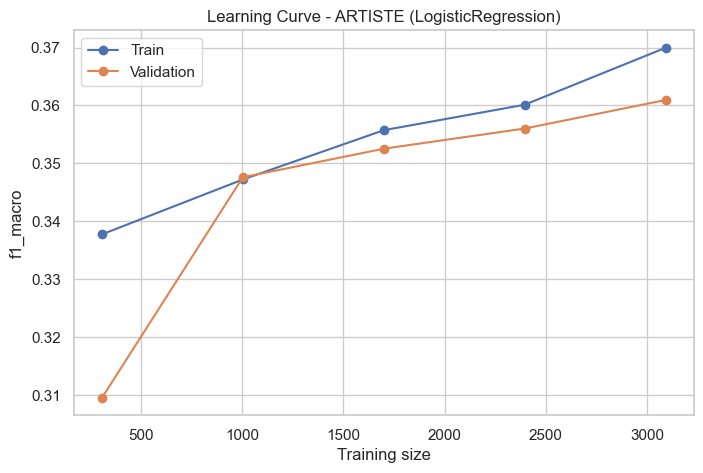

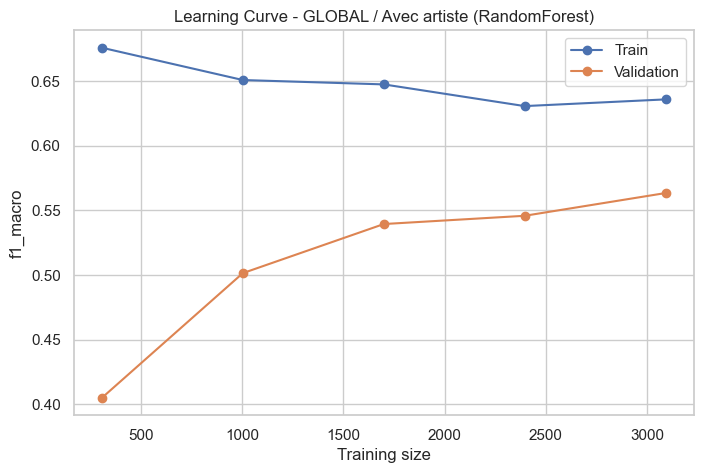

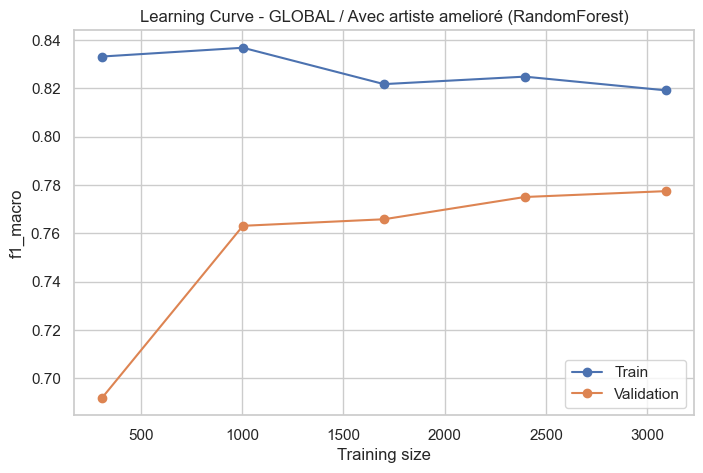

In [93]:
for model in results:
    plot_learning_curve(
        model=model["pipeline"],
        X=X_train,
        y=y_train,
        features=model["features"],
        title=f"Learning Curve - {model['name']}"
    )

<br>
<br>
<br>
<br>

## **13. Tableau comparatif final**

<br>
<br>

Le tableau comparatif final permet de synthétiser les performances des différents modèles en une seule vue. Il offre une lecture claire et directe des principaux indicateurs, facilitant ainsi l’identification du modèle le plus performant et des écarts entre eux.

Dans cette section, les résultats sont regroupés afin de passer d’une analyse détaillée modèle par modèle à une vision globale. L’objectif est de comparer rapidement les performances sur les métriques clés (accuracy, F1-score, etc.) et de mieux comprendre les compromis entre les approches testées.

D’un point de vue technique, les résultats sont rassemblés dans une structure tabulaire à l’aide de `pd.DataFrame`, ce qui permet d’aligner les métriques principales et de simplifier la comparaison globale entre les modèles.

<br>
<br>

In [94]:
print("\n" + "="*100)
print("MODEL COMPARISON")
print("="*100)

for r in eval_results:
    print(
        f"{r['name']} | "
        f"Test Acc={r['test_metrics']['accuracy']:.3f} | "
        f"Test F1={r['test_metrics']['f1_macro']:.3f}"
    )


MODEL COMPARISON
SPOTIFY AUDIO / Sans artiste (LogisticRegression) | Test Acc=0.344 | Test F1=0.310
GLOBAL AUDIO / Sans artiste (LogisticRegression) | Test Acc=0.359 | Test F1=0.325
ARTISTE (LogisticRegression) | Test Acc=0.441 | Test F1=0.378
GLOBAL / Avec artiste (RandomForest) | Test Acc=0.597 | Test F1=0.561
GLOBAL / Avec artiste amelioré (RandomForest) | Test Acc=0.817 | Test F1=0.780
